# Почему пользователи нажимают «Ответ мне не помог»: анализ RAG-чатбота поддержки Ozon

Воспроизводимый ноутбук к исследованию по ТЗ. Отвечает на пять вопросов:

1. **Кластеры популярных вопросов**, по которым чаще всего нажимают «Ответ мне не помог» (далее — ОМНП).
2. **Что отвечает RAG** в этих случаях и есть ли системные проблемы (не по теме, неполный, формальный ответ и т. п.).
3. **Связь ОМНП и «Спасибо, всё понятно»**: где реакция расходится с ожидаемой.
4. **«Хорошие» кластеры ответов-эталонов**.
5. **Гипотезы и рекомендации** с оценкой масштаба.

**Как запустить в Google Colab.** `Runtime → Run all`. Ноутбук сам поставит зависимости, клонирует репозиторий
(нужна папка `data/` с центроидами кластеров и ручной разметкой) и попросит загрузить файл
`Датасет для ВШЭ.xlsx`. Расчёт эмбеддингов занимает ~5 мин на GPU (T4) и ~25 мин на CPU, дальше всё кешируется в `cache/`.

**Как запустить локально.** `pip install -r requirements.txt`, положить датасет в корень репозитория и выполнить ноутбук.

Все случайные процессы зафиксированы (`SEED = 42`). Номера и названия кластеров стабильны:
точки назначаются ближайшему сохранённому центроиду из `data/`. Если центроидов нет, кластеризация
пересчитывается заново, а названия формируются автоматически по ключевым словам.

## 0. Окружение и данные

In [1]:
import sys, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/Artem-Kornilov-pro/Ozon_tech.git'  # репозиторий с папкой data/

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'sentence-transformers>=3', 'statsmodels', 'plotly'], check=False)
    if not Path('/content/Ozon_tech').exists():
        subprocess.run(['git', 'clone', '-q', REPO_URL, '/content/Ozon_tech'], check=False)
    ROOT = Path('/content/Ozon_tech') if Path('/content/Ozon_tech').exists() else Path('/content')
else:
    ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

DATA_DIR, CACHE = ROOT / 'data', ROOT / 'cache'
FIG, TAB, DASH = ROOT / 'outputs' / 'figures', ROOT / 'outputs' / 'tables', ROOT / 'dashboard'
for p in (DATA_DIR, CACHE, FIG, TAB, DASH):
    p.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)

ROOT = /Users/kornilovartemiy/Desktop/Ozon_tech


In [2]:
import re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings('ignore', message='This pattern is interpreted as a regular expression')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)

SEED = 42
EMB_MODEL = 'intfloat/multilingual-e5-small'   # мультиязычная модель, умеет асимметричный поиск query → passage
N_Q_CLUSTERS, N_A_CLUSTERS = 50, 40
OMNP, THANKS = 'Ответ мне не помог', 'Спасибо, всё понятно'
np.random.seed(SEED)

# Единый стиль графиков: оранжевый = ОМНП, синий = «Спасибо», серый = контекст
C_OMNP, C_THX, C_GRAY, C_INK, C_INK2 = '#eb6834', '#2a78d6', '#b5b3ad', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#c9c7c0',
    'axes.labelcolor': C_INK2, 'xtick.color': C_INK2, 'ytick.color': C_INK2,
    'axes.grid': True, 'grid.color': '#ecebe7', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'axes.titlelocation': 'left',
})

def save(fig, name):
    fig.savefig(FIG / f'{name}.png', bbox_inches='tight', facecolor='white')
    plt.show()

In [3]:
DATA_NAME = 'Датасет для ВШЭ.xlsx'
parquet = CACHE / 'dataset.parquet'
if parquet.exists():
    df = pd.read_parquet(parquet)
else:
    candidates = [ROOT / DATA_NAME, DATA_DIR / DATA_NAME, Path('/content') / DATA_NAME]
    data_file = next((p for p in candidates if p.exists()), None)
    if data_file is None and IN_COLAB:
        from google.colab import files
        uploaded = files.upload()                      # выберите «Датасет для ВШЭ.xlsx»
        data_file = Path(next(iter(uploaded)))
    assert data_file is not None, f'Положите {DATA_NAME} в {ROOT}'
    df = pd.read_excel(data_file)
    df.to_parquet(parquet, index=False)

# pandas 3 хранит строки в pyarrow, а его движок регулярок не понимает \b и \w для кириллицы,
# поэтому переводим текст в object: тогда работает стандартный модуль re
for c in ['user_message', 'rag_answer', 'reaction_button']:
    df[c] = df[c].astype(object)
df['omnp'] = (df.reaction_button == OMNP).astype(int)
BASE = df.omnp.mean()
print(df.shape)
print(df.reaction_button.value_counts())
print(f'Базовая доля ОМНП: {BASE:.1%}')
df.head(3)

(119992, 5)
reaction_button
Ответ мне не помог      102028
Спасибо, всё понятно     17964
Name: count, dtype: int64
Базовая доля ОМНП: 85.0%


,id,user_message,rag_answer,reaction_button,omnp
0,1,Главное меню,В мобильном приложении Ozon главное меню открывается через иконку профиля.\n\n1. Авторизуйтесь в приложении.\n2. В н...,Ответ мне не помог,1
1,2,\n\nЗдравствуйте. [УДАЛЕНО] заказ на озон тревел 21 числа был отправлен с Дербента в Питер. Находились 3 флешк...,1. Перейдите в раздел **Отправка** или **Заказы**.\n2. Выберите заказ с номером AA0K60TK6T81-T4KM.\n3. Нажмите **Где...,Ответ мне не помог,1
2,3,Заказ не был получен,"1. Если статус заказа изменился, но вы его не получили, проверьте страницу заказа в личном кабинете.\n2. Если заказ ...",Ответ мне не помог,1


## 1. Данные и их качество

Одна таблица: `id`, `user_message` (вопрос), `rag_answer` (ответ бота), `reaction_button` (одна из двух кнопок).
Важно для интерпретации:
* В выборку попали **только диалоги с нажатой кнопкой**. 85% ОМНП — это не доля плохих ответов бота вообще,
  а структура обратной связи среди тех, кто кликнул. Поэтому сравниваем сегменты **относительно базы 85%**.
* Нет дат, ID сессии и пользователя, найденных фрагментов базы знаний. Многошаговые диалоги восстановить нельзя.
* Персональные данные в вопросах заменены на `[УДАЛЕНО]`, но в ответах встречаются номера заказов:
  маскирование к ответам не применялось.

In [4]:
def norm_q(s):
    s = s.replace('[УДАЛЕНО]', ' ').replace('[ВТБ]', 'ВТБ')
    return re.sub(r'\s+', ' ', s).strip()

def norm_a(s):
    return re.sub(r'\s+', ' ', s).strip()

q_words = df.user_message.map(norm_q).str.split().str.len()
a = df.rag_answer
dq = pd.Series({
    'Строк': len(df),
    'Уникальных вопросов': df.user_message.nunique(),
    'Уникальных ответов': df.rag_answer.nunique(),
    'Полные дубли пары «вопрос + ответ»': df.duplicated(['user_message', 'rag_answer']).sum(),
    'Вопросы из 1–3 слов': (q_words <= 3).sum(),
    'Вопросы с маской [УДАЛЕНО]': df.user_message.str.contains(r'\[УДАЛЕНО\]').sum(),
    'Ответы с номером заказа / трек-номером': a.str.contains(r'\b\d{8,}\b|\b\d{7,}-\d{3,}\b|\b[A-Z0-9]{8,}-[A-Z0-9]{3,}\b').sum(),
    'Ответы с битой Markdown-ссылкой «(url»': a.str.contains(r'\(url(?!\))').sum(),
    'Ответы, обрезанные при выгрузке (≥1050 симв. без точки в конце)':
        ((a.str.len() >= 1050) & ~a.str.rstrip().str[-1].isin(list('.!?)»*'))).sum(),
    'Ответы с иероглифами (артефакт генерации)': a.str.contains(r'[一-鿿]').sum(),
}).to_frame('Значение')
dq['Доля'] = (dq['Значение'] / len(df)).map('{:.1%}'.format)
dq.loc[['Строк', 'Уникальных вопросов', 'Уникальных ответов'], 'Доля'] = ''
dq.to_csv(TAB / '01_data_quality.csv')
dq

,Значение,Доля
Строк,119992,
Уникальных вопросов,101996,
Уникальных ответов,114429,
Полные дубли пары «вопрос + ответ»,1535,1.3%
Вопросы из 1–3 слов,24392,20.3%
Вопросы с маской [УДАЛЕНО],12960,10.8%
Ответы с номером заказа / трек-номером,2994,2.5%
Ответы с битой Markdown-ссылкой «(url»,89129,74.3%
"Ответы, обрезанные при выгрузке (≥1050 симв. без точки в конце)",12331,10.3%
Ответы с иероглифами (артефакт генерации),17,0.0%


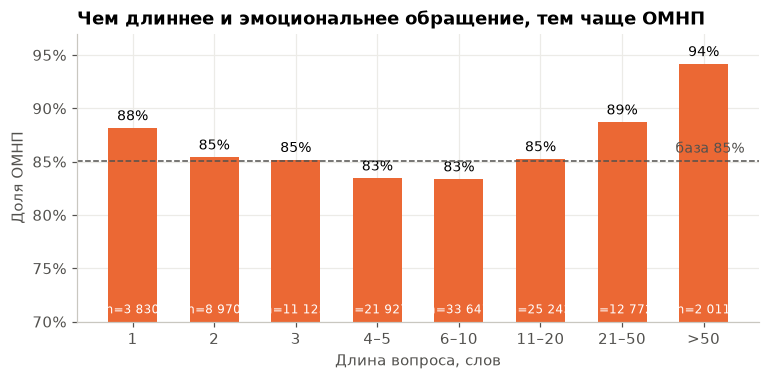

In [5]:
bins = [0, 1, 2, 3, 5, 10, 20, 50, 10_000]
labels = ['1', '2', '3', '4–5', '6–10', '11–20', '21–50', '>50']
t = df.assign(wb=pd.cut(q_words, bins, labels=labels)).groupby('wb', observed=True).omnp.agg(['size', 'mean'])
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(t.index.astype(str), t['mean'], color=C_OMNP, width=0.6)
ax.axhline(BASE, color=C_INK2, ls='--', lw=1)
ax.text(len(t) - 0.5, BASE + 0.005, f'база {BASE:.0%}', ha='right', va='bottom', color=C_INK2, fontsize=9)
for i, (n, m) in enumerate(zip(t['size'], t['mean'])):
    ax.text(i, m + 0.004, f'{m:.0%}', ha='center', va='bottom', fontsize=9)
    ax.text(i, 0.705, f'n={n:,}'.replace(',', ' '), ha='center', va='bottom', fontsize=8, color='white')
ax.set_ylim(0.7, 0.97); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlabel('Длина вопроса, слов'); ax.set_ylabel('Доля ОМНП')
ax.set_title('Чем длиннее и эмоциональнее обращение, тем чаще ОМНП')
save(fig, '01_omnp_by_length')

## 2. Эмбеддинги вопросов и ответов

`multilingual-e5-small`: вопросы кодируем с префиксом `query:`, ответы — с `passage:`.
Косинусная близость вопроса и ответа служит прокси **релевантности** ответа запросу.

In [6]:
def embed(texts: pd.Series, prefix: str, path: Path) -> np.ndarray:
    if path.exists():
        return np.load(path)
    import torch
    from sentence_transformers import SentenceTransformer
    device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
    model = SentenceTransformer(EMB_MODEL, device=device)
    model.max_seq_length = 256
    uniq = pd.unique(texts)
    E = model.encode([prefix + t for t in uniq], batch_size=64, normalize_embeddings=True,
                     show_progress_bar=True).astype(np.float32)
    pos = pd.Series(np.arange(len(uniq)), index=uniq)
    out = E[pos[texts].values]
    np.save(path, out)
    return out

q_text = df.user_message.map(lambda s: norm_q(s) or '<пусто>').astype(object)
a_text = df.rag_answer.map(norm_a).astype(object)
EQ = embed(q_text, 'query: ', CACHE / 'emb_questions.npy')
EA = embed(a_text, 'passage: ', CACHE / 'emb_answers.npy')
df['qa_sim'] = (EQ * EA).sum(1)
print(EQ.shape, EA.shape)
df.qa_sim.describe(percentiles=[.1, .25, .5, .75, .9]).round(3)

(119992, 384) (119992, 384)


count    119992.000
mean          0.868
std           0.033
min           0.703
10%           0.823
25%           0.848
50%           0.872
75%           0.892
90%           0.907
max           0.976
Name: qa_sim, dtype: float64

## 3. Кластеры вопросов

KMeans (k = 50) на эмбеддингах вопросов, затем ручное именование по ключевым словам (c-TF-IDF) и примерам.
Кластеры сгруппированы в 16 макротем. Значение k выбрано по силуэту (0.073 при k = 50 против 0.065 при k = 40)
и по интерпретируемости. Силуэт низкий при любом k, для коротких текстов это нормально.

Кластеры получились двух типов: **тематические** («отменить заказ», «где мой заказ», «Premium», «баллы»…)
и **по форме запроса** («развёрнутые жалобы», «однословные кнопки меню», «ответ не помог / вопрос выше»).
Второй тип — тоже результат: форма запроса сильно связана с ОМНП.

In [7]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

def nearest_centroid(E, C):
    return (-2 * E @ C.T + (C ** 2).sum(1)[None]).argmin(1)

def ctfidf_keywords(texts, labels, top=6):
    docs = pd.Series(texts).groupby(labels).apply(' '.join)
    cv = CountVectorizer(token_pattern=r'(?u)\b[а-яёa-z]{3,}\b', max_features=20000)
    T = TfidfTransformer().fit_transform(cv.fit_transform(docs)).toarray()
    voc = np.array(cv.get_feature_names_out())
    return {c: ', '.join(voc[T[i].argsort()[::-1][:top]]) for i, c in enumerate(docs.index)}

def cluster(E, k, centroid_file, names_file, texts):
    if centroid_file.exists():
        labels = nearest_centroid(E, np.load(centroid_file))
        names = pd.read_csv(names_file).set_index('cluster')
        print(f'{centroid_file.name}: назначение по сохранённым центроидам')
    else:
        km = KMeans(k, random_state=SEED, n_init=3).fit(E)
        labels = km.labels_
        np.save(centroid_file, km.cluster_centers_)
        kw = ctfidf_keywords(texts, labels)
        names = pd.DataFrame({'name': kw}).rename_axis('cluster')
        names['theme'] = names['name']
        print(f'{centroid_file.name}: центроидов не было, кластеризация пересчитана, названия автоматические')
    return labels, names

df['q_cluster'], qnames = cluster(EQ, N_Q_CLUSTERS, DATA_DIR / 'question_centroids.npy',
                                  DATA_DIR / 'question_clusters.csv', q_text.str.lower())
df['q_name'] = df.q_cluster.map(qnames['name'])
df['theme'] = df.q_cluster.map(qnames['theme'])
kw = ctfidf_keywords(q_text.str.lower(), df.q_cluster)

question_centroids.npy: назначение по сохранённым центроидам


In [8]:
def wilson(k, n, z=1.96):
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h

def rate_table(data, by, min_n=0):
    g = data.groupby(by, observed=True)['omnp'].agg(n='size', omnp_n='sum')
    g['omnp_rate'] = g.omnp_n / g.n
    g['ci_low'], g['ci_high'] = wilson(g.omnp_n, g.n)
    g['traffic_share'] = g.n / len(data)
    g['omnp_share'] = g.omnp_n / data.omnp.sum()
    g['lift_pp'] = (g.omnp_rate - BASE) * 100
    g['excess_omnp'] = g.omnp_n - g.n * BASE
    return g[g.n >= min_n].sort_values('omnp_n', ascending=False)

theme_t = rate_table(df, 'theme')
theme_t.to_csv(TAB / '03_themes.csv')
clu_t = rate_table(df, ['q_cluster', 'q_name', 'theme'])
clu_t['keywords'] = [kw[c] for c in clu_t.index.get_level_values(0)]
clu_t['top_questions'] = [' | '.join(df.loc[df.q_cluster == c, 'user_message'].str.strip().str.lower()
                                     .value_counts().head(3).index.str[:40]) for c in clu_t.index.get_level_values(0)]
clu_t.to_csv(TAB / '03_question_clusters.csv')
theme_t.style.format({'omnp_rate': '{:.1%}', 'ci_low': '{:.1%}', 'ci_high': '{:.1%}', 'traffic_share': '{:.1%}',
                      'omnp_share': '{:.1%}', 'lift_pp': '{:+.1f}', 'excess_omnp': '{:+.0f}'})

,n,omnp_n,omnp_rate,ci_low,ci_high,traffic_share,omnp_share,lift_pp,excess_omnp
theme,,,,,,,,,
Статус и сроки доставки,17923,15854,88.5%,88.0%,88.9%,14.9%,15.5%,+3.4,+614
Жалобы и развёрнутые обращения,16061,14258,88.8%,88.3%,89.3%,13.4%,14.0%,+3.7,+601
Кнопки меню и неинформативные запросы,12100,10178,84.1%,83.5%,84.8%,10.1%,10.0%,-0.9,-111
"Списания, банк и рассрочка",10224,8441,82.6%,81.8%,83.3%,8.5%,8.3%,-2.5,-252
"Баллы, сертификаты, промокоды",9074,6907,76.1%,75.2%,77.0%,7.6%,6.8%,-8.9,-809
Отмена заказа,7173,6332,88.3%,87.5%,89.0%,6.0%,6.2%,+3.2,+233
Оплата,7272,5877,80.8%,79.9%,81.7%,6.1%,5.8%,-4.2,-306
Проблемы с получением заказа,5884,5477,93.1%,92.4%,93.7%,4.9%,5.4%,+8.1,+474
"Продавец, товар, отзывы",6200,5345,86.2%,85.3%,87.0%,5.2%,5.2%,+1.2,+73


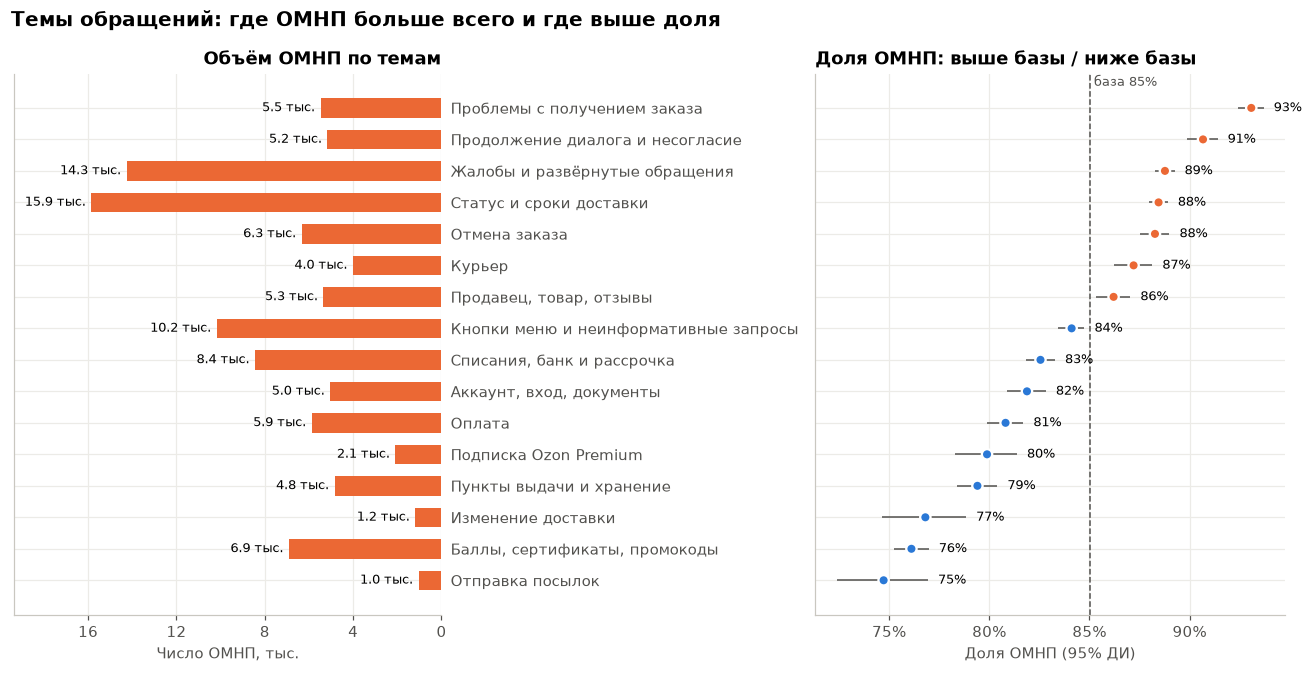

In [9]:
t = theme_t.sort_values('omnp_rate')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6.2), sharey=True, gridspec_kw={'width_ratios': [1, 1.1]})
y = np.arange(len(t))
ax1.barh(y, t.omnp_n, color=C_OMNP, height=0.62)
for i, v in enumerate(t.omnp_n):
    ax1.text(v + 250, i, f'{v/1000:.1f} тыс.', va='center', ha='right', fontsize=8.5)
ax1.set_yticks(y, t.index); ax1.set_xlim(t.omnp_n.max() * 1.22, 0); ax1.set_xlabel('Число ОМНП, тыс.')
ax1.xaxis.set_major_locator(mtick.MultipleLocator(4000))
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1000:.0f}'))
ax1.set_title('Объём ОМНП по темам', loc='right')
ax1.yaxis.tick_right(); ax1.tick_params(axis='y', length=0, pad=6)
colors = [C_OMNP if lo > BASE else (C_THX if hi < BASE else C_GRAY) for lo, hi in zip(t.ci_low, t.ci_high)]
ax2.errorbar(t.omnp_rate, y, xerr=[t.omnp_rate - t.ci_low, t.ci_high - t.omnp_rate], fmt='none', ecolor=C_INK2, lw=1)
ax2.scatter(t.omnp_rate, y, s=46, color=colors, zorder=3, edgecolor='white', linewidth=1.5)
ax2.axvline(BASE, color=C_INK2, ls='--', lw=1); ax2.text(BASE, len(t) - 0.3, f' база {BASE:.0%}', fontsize=8.5, color=C_INK2)
for i, (v, h) in enumerate(zip(t.omnp_rate, t.ci_high)):
    ax2.text(h + 0.005, i, f'{v:.0%}', va='center', fontsize=8.5)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax2.set_xlabel('Доля ОМНП (95% ДИ)')
ax2.set_title('Доля ОМНП: выше базы / ниже базы')
ax2.tick_params(axis='y', length=0)
fig.suptitle('Темы обращений: где ОМНП больше всего и где выше доля', x=0.01, ha='left', fontweight='bold', fontsize=13)
fig.tight_layout()
save(fig, '02_themes')

In [10]:
# Топ кластеров по «избыточным» ОМНП (сколько ОМНП сверх ожидаемого при базовой доле)
top = clu_t[clu_t.n >= 300].sort_values('excess_omnp', ascending=False)
cols = ['n', 'omnp_rate', 'lift_pp', 'excess_omnp', 'omnp_share', 'keywords']
print('Кластеры с наибольшим избытком ОМНП')
display(top.head(12)[cols].style.format({'omnp_rate': '{:.1%}', 'lift_pp': '{:+.1f}', 'excess_omnp': '{:+.0f}', 'omnp_share': '{:.1%}'}))
print('Кластеры с наименьшей долей ОМНП')
display(clu_t[clu_t.n >= 300].sort_values('omnp_rate').head(10)[cols].style.format(
    {'omnp_rate': '{:.1%}', 'lift_pp': '{:+.1f}', 'excess_omnp': '{:+.0f}', 'omnp_share': '{:.1%}'}))

Кластеры с наибольшим избытком ОМНП


,,,n,omnp_rate,lift_pp,excess_omnp,omnp_share,keywords
q_cluster,q_name,theme,,,,,,
0,Развёрнутые претензии и жалобы (разные темы),Жалобы и развёрнутые обращения,6640,90.3%,+5.3,+350,5.9%,"что, заказ, товар, мне, как, его"
31,«Не могу… / нет…»: короткие описания проблем,Проблемы с получением заказа,3743,93.3%,+8.2,+308,3.4%,"заказ, могу, нет, товар, заказа, мне"
17,Задержка доставки: подробные жалобы,Статус и сроки доставки,4417,91.9%,+6.9,+303,4.0%,"заказ, доставки, уже, что, сентября, товар"
32,"«Ответ не помог», «нет», несогласие с ботом",Продолжение диалога и несогласие,2436,94.3%,+9.3,+226,2.3%,"нет, помог, мне, ответ, поможешь, его"
41,Переносы доставки и долгое ожидание,Статус и сроки доставки,3176,91.2%,+6.1,+194,2.8%,"заказ, уже, дней, доставки, сентября, день"
13,Развёрнутое описание проблемы с заказом,Жалобы и развёрнутые обращения,5668,88.2%,+3.2,+182,4.9%,"заказ, мне, что, товар, здравствуйте, меня"
18,Заказ не доставлен / не меняется статус,Проблемы с получением заказа,2141,92.8%,+7.7,+166,1.9%,"заказ, нет, товар, выдачи, работает, заказа"
11,«Отменить заказ» (команда),Отмена заказа,3882,89.0%,+4.0,+155,3.4%,"отменить, заказ, отмените, отмена, заказа, хочу"
14,Курьер: жалобы и проблемы доставки,Курьер,2521,90.9%,+5.8,+147,2.2%,"курьер, заказ, что, курьера, мне, курьером"


Кластеры с наименьшей долей ОМНП


,,,n,omnp_rate,lift_pp,excess_omnp,omnp_share,keywords
q_cluster,q_name,theme,,,,,,
35,Продлить срок хранения,Пункты выдачи и хранение,1484,64.7%,-20.3,-302,0.9%,"продлить, хранения, срок, хранение, можно, как"
23,"Где найти чеки, промокоды","Баллы, сертификаты, промокоды",2118,69.0%,-16.0,-340,1.4%,"где, как, чек, найти, посмотреть, промокод"
30,"Баллы, ВАУ-баллы, баланс (коротко)","Баллы, сертификаты, промокоды",1586,69.7%,-15.4,-244,1.1%,"баллы, вау, как, баллов, балы, почему"
12,Отключить Ozon Premium,Подписка Ozon Premium,1159,70.7%,-14.4,-166,0.8%,"премиум, озон, отключить, подписку, как, отменить"
21,«Главное меню» / пустое сообщение,Кнопки меню и неинформативные запросы,761,72.4%,-12.6,-96,0.5%,"пусто, главное, меню, пуш, такое, что"
2,Способы оплаты и постоплата,Оплата,2125,72.8%,-12.2,-259,1.5%,"оплатить, как, заказ, оплата, можно, при"
33,Отправить посылку (Ozon Доставка),Отправка посылок,1389,74.7%,-10.3,-143,1.0%,"посылку, отправить, как, посылка, посылки, озон"
36,"Отключить подписки, удалить аккаунт, уведомления","Аккаунт, вход, документы",1884,74.9%,-10.1,-191,1.4%,"как, отключить, подписку, аккаунт, удалить, отменить"
38,Рассрочка,"Списания, банк и рассрочка",1058,75.5%,-9.5,-101,0.8%,"рассрочку, рассрочка, рассрочки, как, лимит, рассрочке"


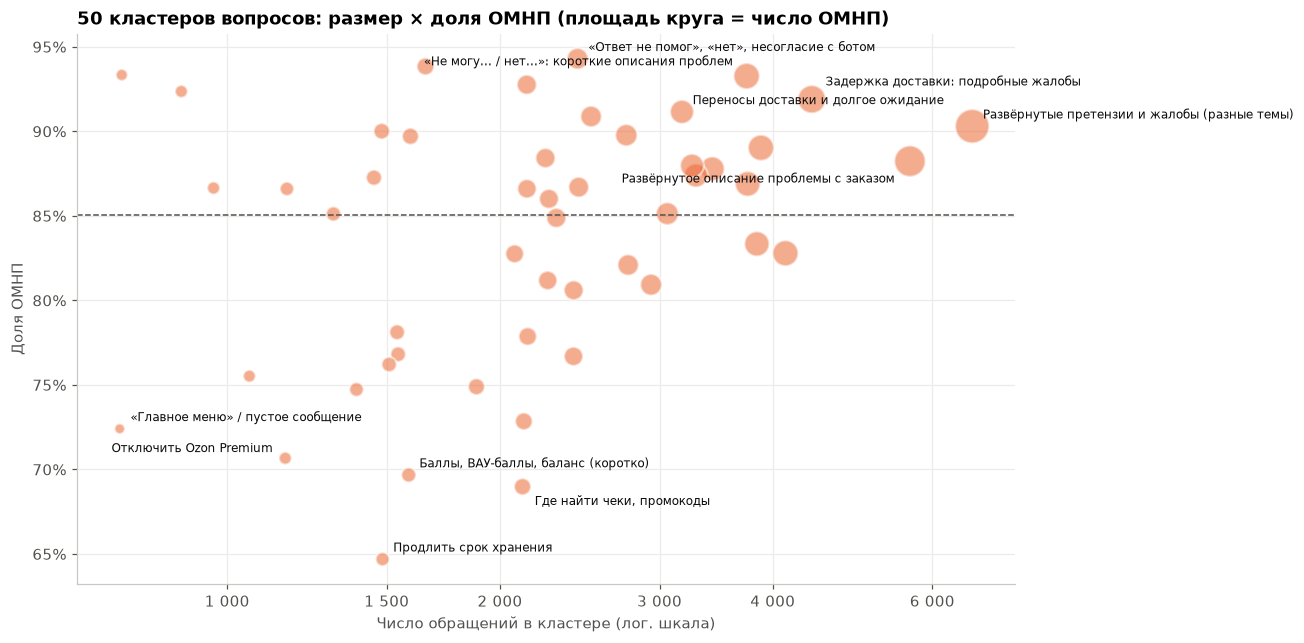

In [11]:
t = clu_t[clu_t.n >= 300].reset_index()
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(t.n, t.omnp_rate, s=np.clip(t.omnp_n / 12, 20, 600), color=C_OMNP, alpha=0.55, edgecolor='white', linewidth=1.5)
ax.axhline(BASE, color=C_INK2, ls='--', lw=1)
ax.set_xscale('log'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.xaxis.set_major_locator(mtick.FixedLocator([1000, 1500, 2000, 3000, 4000, 6000]))
ax.xaxis.set_minor_locator(mtick.NullLocator())
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
lab = pd.concat([t.nlargest(6, 'excess_omnp'), t.nsmallest(5, 'omnp_rate')]).drop_duplicates('q_cluster')
# ручные смещения подписей, чтобы они не накладывались (названия кластеров фиксированы в data/)
OFFSETS = {'«Не могу… / нет…»: короткие описания проблем': (-9, 7, 'right'),
           'Задержка доставки: подробные жалобы': (9, 9, 'left'),
           'Отключить Ozon Premium': (-8, 4, 'right'),
           'Где найти чеки, промокоды': (8, -12, 'left'),
           'Развёрнутое описание проблемы с заказом': (-10, -14, 'right')}
for _, r in lab.iterrows():
    dx, dy, ha = OFFSETS.get(r.q_name, (7, 5, 'left'))
    ax.annotate(r.q_name, (r.n, r.omnp_rate), xytext=(dx, dy), textcoords='offset points', ha=ha, fontsize=8, color=C_INK)
ax.set_xlabel('Число обращений в кластере (лог. шкала)'); ax.set_ylabel('Доля ОМНП')
ax.set_title('50 кластеров вопросов: размер × доля ОМНП (площадь круга = число ОМНП)')
save(fig, '03_clusters_scatter')

## 4. Что на самом деле нужно пользователю: тип намерения

Правилами (регулярные выражения) определяем, **что хочет человек**, независимо от темы.
Правила проверены на ручной разметке 210 диалогов (см. раздел 5).
* **Узнать**: информационный вопрос («как…», «можно ли…», «почему…?»).
* **Решить по своему заказу**: статус («где мой заказ»), проблема («не пришёл», «списали»), просьба о действии («отмените»).
* **Эскалация**: жалоба или эмоции (`!!!`, капс, «обман», «суд»), прямой запрос оператора.
* **Неясный запрос**: кнопка или тема без вопроса («Рассрочка»), продолжение диалога («вопрос выше»), прочие утверждения.

In [12]:
QP = dict(
    human=r'\b(человек|оператор\w*|специалист\w*|живо\w+|сотрудник\w* поддержки|соедини\w*|позовите|переключите)\b',
    followup=r'(не помог|не ответил|не отвечаете|вопрос выше|см\.? выше|описан\w* выше|указан\w* выше|^нет[.!]*$|^да[.!]*$|^не то\b|^это не\b|не этот|не тот вопрос|я же (?:писал|сказал|спрашивал)|я уже (?:писал|спрашивал|сделал)|опять|снова|одно и то же|тот же ответ|\bбот\b|робот|^\W*$|^(?:а|и|но|так|ну)\s)',
    status=r'(где\s+(?:мой|мои|моя|наш|сейчас|находится)?\s*(?:заказ|товар|посылк|покупк|доставк)|когда\s+(?:при|при?е|будет|достав|прив)\w*|статус\w*|трек|отслед\w*|где\s+курьер|долго\s+(?:ещ[её]|ждать|везут|идет|идёт)|задерж\w*|перенос\w*|перенесл\w*|до сих пор)',
    problem=r'(не\s+при(?:шел|шёл|шла|шли|ходит|ходят|езжает)|не\s+достав|не\s+получ|не\s+могу|не\s+работает|не\s+проход|не\s+отобража|не\s+видно|не\s+вижу|не\s+начисл|не\s+вернул|не\s+поступ|не\s+отвечает|списал\w*|сняли|сняты|пропал\w*|исчез\w*|потерял\w*|обман\w*|ошибк\w*|не\s+та\b|не\s+тот\b|брак|сломан|поврежд)',
    action=r'^(?:отмен|верн|возвра|продл|перенес|измен|помен|смен|отключ|удал|вызов|вызва|оформ|сдела|откаж|закр|подключ|активир|компенс)\w*|\b(?:отмените|верните|продлите|перенесите|измените|поменяйте|отключите|удалите|сделайте|вызовите|оформите|закройте|снимите|разблокируйте|компенсируйте|начислите|пришлите|отправьте|хочу|прошу|требую|нужно|надо|помогите)\b',
    info=r'^(?:как|где|можно|могу|почему|что|когда|сколько|какой|какая|какие|зачем|куда|откуда|есть ли|подскажите|скажите|объясните)\b|\?',
)
EMO = r'(!{2,}|\?{3,}|безобраз|издева|обман|мошенн|кошмар|ужас|отврат|позор|бред|черт|хрен|суд\b|роспотреб|прокурат|претензи)'
INTENT_GROUP = {
    'Информационный вопрос': 'Узнать',
    'Статус заказа': 'Решить по своему заказу', 'Проблема': 'Решить по своему заказу',
    'Просьба о действии': 'Решить по своему заказу',
    'Жалоба / эмоции': 'Эскалация', 'Запрос оператора': 'Эскалация',
    'Кнопка / тема без вопроса': 'Неясный запрос', 'Продолжение диалога': 'Неясный запрос',
    'Прочее утверждение': 'Неясный запрос',
}

def q_features(msg: pd.Series) -> pd.DataFrame:
    raw = msg.fillna('').astype(object)
    q = raw.map(norm_q).str.lower().astype(object)
    f = pd.DataFrame(index=msg.index)
    f['q_words'] = q.str.split().str.len().fillna(0).astype(int)
    f['q_short'] = f.q_words <= 3
    f['q_long'] = f.q_words > 30
    f['q_order_ref'] = raw.str.contains(r'\[УДАЛЕНО\]') | q.str.contains(r'заказ\w*\s*№|\b\d{6,}\b|\d{8}-\d{4}')
    letters = raw.str.replace(r'[^А-ЯЁA-Zа-яёa-z]', '', regex=True)
    caps = letters.str.count(r'[А-ЯЁA-Z]') / letters.str.len().clip(lower=1)
    f['q_emotional'] = q.str.contains(EMO) | ((caps > 0.6) & (letters.str.len() > 10))
    for k, p in QP.items():
        f['q_' + k] = q.str.contains(p)
    f['intent'] = np.select(
        [f.q_human, f.q_followup & (f.q_words <= 12), f.q_emotional | f.q_long,
         f.q_status, f.q_problem, f.q_action, f.q_info, f.q_short],
        ['Запрос оператора', 'Продолжение диалога', 'Жалоба / эмоции', 'Статус заказа', 'Проблема',
         'Просьба о действии', 'Информационный вопрос', 'Кнопка / тема без вопроса'],
        default='Прочее утверждение')
    f['need'] = f.intent.map(INTENT_GROUP)
    return f

QF = q_features(df.user_message)
df = df.join(QF)
intent_t = rate_table(df, ['need', 'intent'])
intent_t.to_csv(TAB / '04_intents.csv')
intent_t.style.format({'omnp_rate': '{:.1%}', 'ci_low': '{:.1%}', 'ci_high': '{:.1%}', 'traffic_share': '{:.1%}',
                       'omnp_share': '{:.1%}', 'lift_pp': '{:+.1f}', 'excess_omnp': '{:+.0f}'})

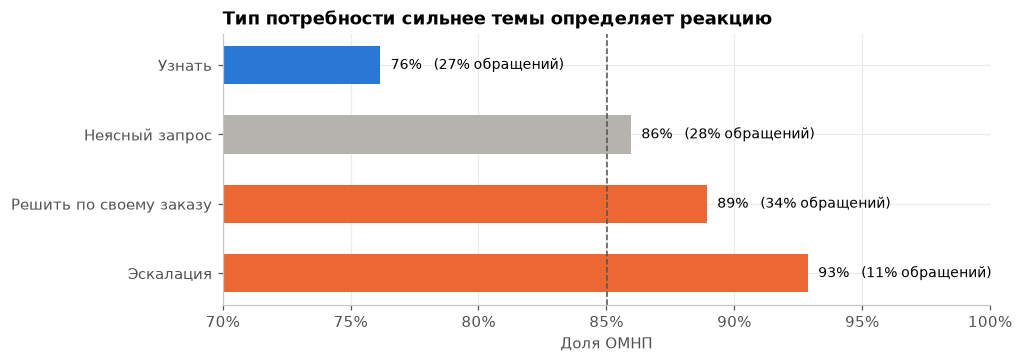

In [13]:
NEED_ORDER = ['Узнать', 'Неясный запрос', 'Решить по своему заказу', 'Эскалация']
t = rate_table(df, 'need').reindex(NEED_ORDER)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(NEED_ORDER, t.omnp_rate, color=[C_THX, C_GRAY, C_OMNP, C_OMNP], height=0.55)
ax.axvline(BASE, color=C_INK2, ls='--', lw=1)
for i, (r, s) in enumerate(zip(t.omnp_rate, t.traffic_share)):
    ax.text(r + 0.004, i, f'{r:.0%}   ({s:.0%} обращений)', va='center', fontsize=9)
ax.set_xlim(0.7, 1.0); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.invert_yaxis()
ax.set_title('Тип потребности сильнее темы определяет реакцию'); ax.set_xlabel('Доля ОМНП')
save(fig, '04_need')

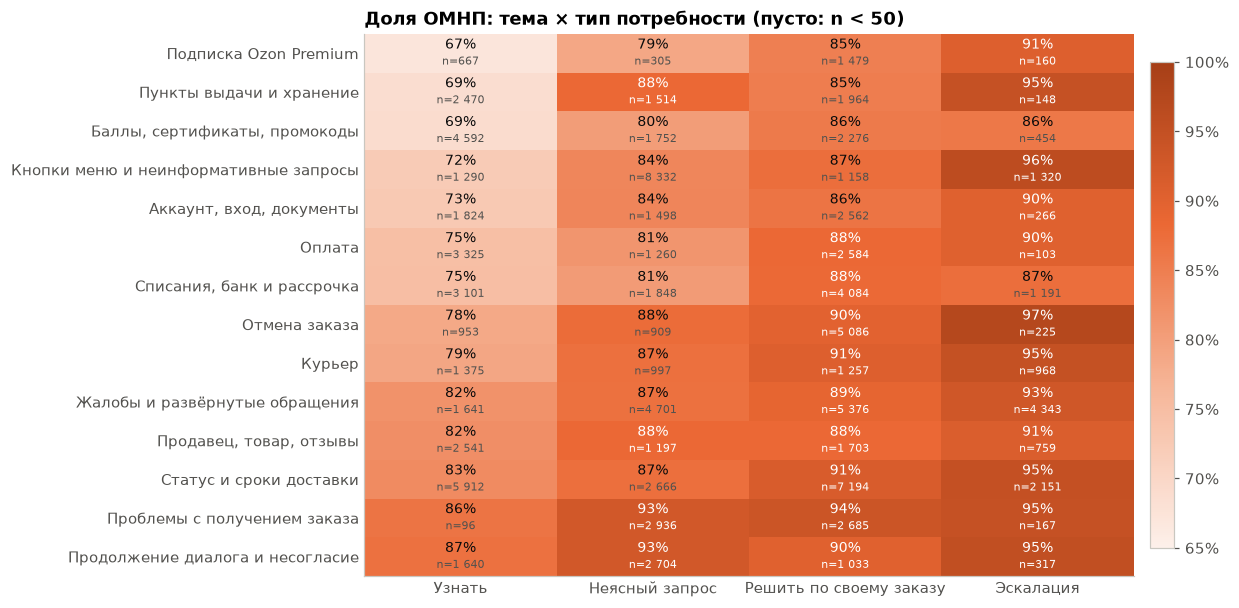

In [14]:
top_themes = theme_t.sort_values('n', ascending=False).index[:14]
hm = df[df.theme.isin(top_themes)].pivot_table(index='theme', columns='need', values='omnp', aggfunc='mean')[NEED_ORDER]
hn = df[df.theme.isin(top_themes)].pivot_table(index='theme', columns='need', values='omnp', aggfunc='size')[NEED_ORDER]
hm = hm.loc[hm['Узнать'].sort_values().index]
hn = hn.loc[hm.index]
fig, ax = plt.subplots(figsize=(9.5, 6.4))
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('seq', ['#fdf0ea', '#f6b597', '#eb6834', '#a63f17'])
im = ax.imshow(hm.where(hn >= 50), cmap=cmap, vmin=0.65, vmax=1.0, aspect='auto')
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        if hn.iat[i, j] >= 50:
            v = hm.iat[i, j]
            ax.text(j, i, f'{v:.0%}\n', ha='center', va='center', fontsize=9, color='white' if v > 0.88 else C_INK)
            ax.text(j, i + 0.22, f'n={hn.iat[i, j]:,}'.replace(',', ' '), ha='center', va='center', fontsize=7, color='white' if v > 0.88 else C_INK2)
ax.set_xticks(range(len(NEED_ORDER)), NEED_ORDER); ax.set_yticks(range(len(hm)), hm.index)
ax.grid(False); ax.tick_params(length=0)
ax.set_title('Доля ОМНП: тема × тип потребности (пусто: n < 50)')
fig.colorbar(im, ax=ax, format=mtick.PercentFormatter(1, decimals=0), fraction=0.03, pad=0.02)
save(fig, '05_theme_need_heatmap')

Внутри **одной темы** информационный вопрос получает ОМНП заметно реже, чем просьба решить что-то по своему заказу.
Значит, дело не столько в теме, сколько в том, что бот **отвечает справкой на запрос действия**.

## 5. Что отвечает RAG: системные проблемы

### 5.1 Ручная разметка 210 диалогов
Случайная выборка: 150 ОМНП + 60 «Спасибо» (`random_state=42`). Каждому диалогу присвоена **основная причина**
(одна метка), разметка хранится в `data/manual_labels.csv`.

In [15]:
LABELS = {
    'A': 'Нужно действие / данные по своему заказу',
    'I': 'Ответ по теме, но общий / неполный',
    'G': 'Ответ корректный и по существу',
    'C': 'Продолжение диалога: бот не видит контекст',
    'E': 'Жалоба / нужен оператор: бот даёт справку',
    'P': 'Корректный отказ по правилам («нельзя»)',
    'V': 'Неясный запрос: бот угадывает',
    'O': 'Ответ не по теме (неверно понят запрос)',
    'K': 'Нет информации в базе знаний',
}
ml_path = DATA_DIR / 'manual_labels.csv'
HAS_LABELS = ml_path.exists()
if HAS_LABELS:
    ml = pd.read_csv(ml_path).merge(df[['id', 'intent', 'need', 'theme', 'qa_sim']], on='id')
    ml['label_name'] = ml.label.map(LABELS)
    ct = pd.crosstab(ml.label_name, ml.reaction)
    ct['ОМНП, %'] = (ct['ОМНП'] / ct['ОМНП'].sum() * 100).round(1)
    ct['Спасибо, %'] = (ct['Спасибо'] / ct['Спасибо'].sum() * 100).round(1)
    lo, hi = wilson(ct['ОМНП'], ct['ОМНП'].sum())
    ct['ОМНП 95% ДИ'] = [f'{l:.0%}–{h:.0%}' for l, h in zip(lo, hi)]
    ct = ct.sort_values('ОМНП', ascending=False)
    ct.to_csv(TAB / '05_manual_labels.csv')
    display(ct)

reaction,ОМНП,Спасибо,"ОМНП, %","Спасибо, %",ОМНП 95% ДИ
label_name,,,,,
Нужно действие / данные по своему заказу,50,7,33.3,11.7,26%–41%
Ответ корректный и по существу,26,41,17.3,68.3,12%–24%
"Ответ по теме, но общий / неполный",22,5,14.7,8.3,10%–21%
Продолжение диалога: бот не видит контекст,12,0,8.0,0.0,5%–13%
Жалоба / нужен оператор: бот даёт справку,11,1,7.3,1.7,4%–13%
Корректный отказ по правилам («нельзя»),9,6,6.0,10.0,3%–11%
Неясный запрос: бот угадывает,9,0,6.0,0.0,3%–11%
Ответ не по теме (неверно понят запрос),6,0,4.0,0.0,2%–8%
Нет информации в базе знаний,5,0,3.3,0.0,1%–8%


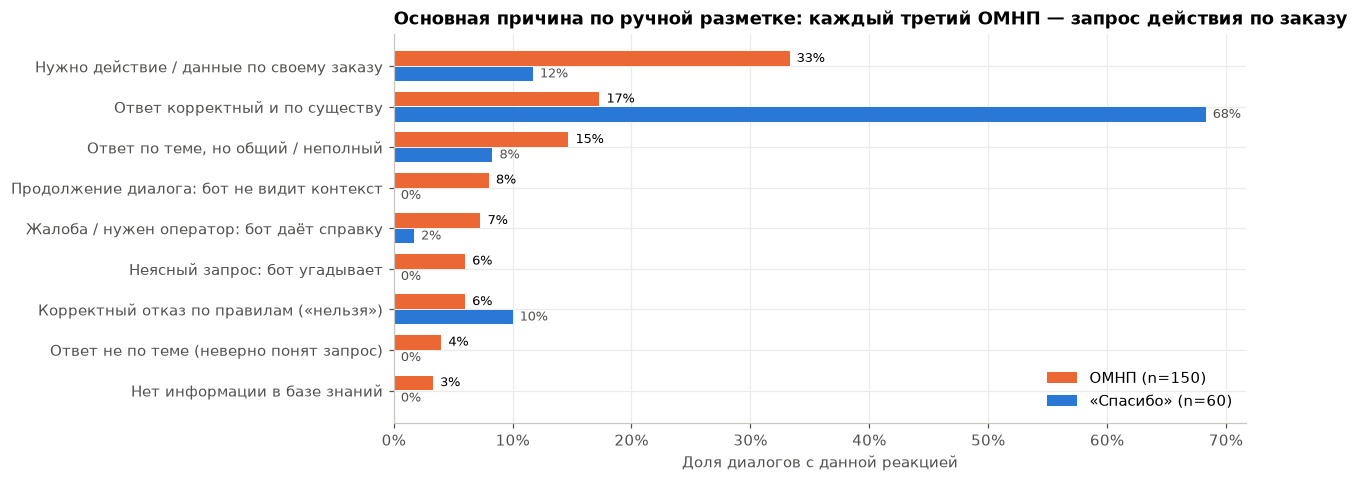

In [16]:
if HAS_LABELS:
    t = ct.sort_values('ОМНП, %')
    fig, ax = plt.subplots(figsize=(10, 4.6))
    yy = np.arange(len(t))
    ax.barh(yy + 0.19, t['ОМНП, %'], height=0.36, color=C_OMNP, label='ОМНП (n=150)')
    ax.barh(yy - 0.19, t['Спасибо, %'], height=0.36, color=C_THX, label='«Спасибо» (n=60)')
    for i, (o, s) in enumerate(zip(t['ОМНП, %'], t['Спасибо, %'])):
        ax.text(o + 0.6, i + 0.19, f'{o:.0f}%', va='center', fontsize=8.5)
        ax.text(s + 0.6, i - 0.19, f'{s:.0f}%', va='center', fontsize=8.5, color=C_INK2)
    ax.set_yticks(yy, t.index); ax.xaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))
    ax.legend(loc='lower right', frameon=False); ax.set_xlabel('Доля диалогов с данной реакцией')
    ax.set_title('Основная причина по ручной разметке: каждый третий ОМНП — запрос действия по заказу')
    save(fig, '06_manual_taxonomy')

In [17]:
# Насколько правила из раздела 4 согласуются с ручной разметкой
if HAS_LABELS:
    display(pd.crosstab(ml.need, ml.label, margins=True))
    a_in_solve = (ml.loc[ml.label == 'A', 'need'].isin(['Решить по своему заказу', 'Эскалация'])).mean()
    g_in_info = (ml.loc[ml.label == 'G', 'need'] == 'Узнать').mean()
    print(f'Метка A («нужно действие») попала в «Решить по заказу» или «Эскалацию»: {a_in_solve:.0%}')
    print(f'Метка G («корректный ответ») приходится на «Узнать»: {g_in_info:.0%}')

label,A,C,E,G,I,K,O,P,V,All
need,,,,,,,,,,
Неясный запрос,13,9,4,15,3,1,0,2,7,54
Решить по своему заказу,30,1,1,14,15,1,4,3,1,70
Узнать,5,1,0,36,8,2,2,9,0,63
Эскалация,9,1,7,2,1,1,0,1,1,23
All,57,12,12,67,27,5,6,15,9,210


Метка A («нужно действие») попала в «Решить по заказу» или «Эскалацию»: 68%
Метка G («корректный ответ») приходится на «Узнать»: 54%


### 5.2 Признаки ответов в масштабе всего датасета
Типы ответа ищем правилами. Пример: **список причин** — «оплата может не пройти по следующим причинам: …»
вместо ответа про конкретный случай.

In [18]:
def a_features(ans: pd.Series) -> pd.DataFrame:
    a = ans.astype(object)
    head = a.str[:250]
    f = pd.DataFrame(index=a.index)
    f['a_chars'] = a.str.len()
    f['a_steps'] = a.str.count(r'(?m)^\s*\d+\.\s')
    f['a_yesno'] = a.str.match(r'^\s*(?:Да|Нет)\b')
    f['a_refusal'] = head.str.contains(r'нельзя|невозможно|не получится|не предусмотрен|не принимаются', case=False)
    f['a_instruction'] = (f.a_steps >= 2) | a.str.contains('выполните следующие', case=False)
    f['a_lk_redirect'] = head.str.contains(r'личн\w+ кабинет|раздел\w*\s+\[?\*\*Заказы|Где заказ', case=False)
    f['a_reasons_list'] = head.str.contains(r'по следующим причинам|может быть связан|могут быть|возможные причины|по разным причинам', case=False)
    f['a_no_info'] = a.str.contains(r'нет информаци|отсутствует информаци|информация .{0,40}отсутствует|в базе знаний (?:нет|не )|не содержит информаци|в найденной информации', case=False)
    f['a_order_echo'] = a.str.contains(r'\b\d{8,}\b|\b\d{7,}-\d{3,}\b|\b[A-Z0-9]{8,}-[A-Z0-9]{3,}\b')
    f['a_concrete'] = a.str.contains(r'\d+\s?(?:дн|день|дня|дней|час|мин|руб|₽|%|раб)', case=False)
    f['a_template'] = a.map(a.value_counts()) >= 20
    return f

AF = a_features(df.rag_answer)
df = df.join(AF)
LOW_SIM = df.qa_sim.quantile(0.2)
df['a_low_rel'] = df.qa_sim < LOW_SIM

FLAG_NAMES = {
    'a_low_rel': 'Низкая релевантность (нижние 20% по близости вопрос–ответ)',
    'a_lk_redirect': 'Отсылка в личный кабинет в начале ответа',
    'a_instruction': 'Пошаговая инструкция «сделайте сами»',
    'a_reasons_list': 'Список возможных причин вместо ответа',
    'a_template': 'Шаблонный ответ (тот же текст ≥ 20 раз)',
    'a_refusal': 'Отказ / ограничение в начале ответа',
    'a_order_echo': 'Номер заказа в ответе без данных по нему',
    'a_no_info': '«Нет информации в базе знаний»',
    'a_yesno': 'Прямой ответ «Да» / «Нет» первым словом',
    'a_concrete': 'Конкретные сроки / суммы / проценты',
}
rows = []
for k, name in FLAG_NAMES.items():
    m = df[k].astype(bool)
    rows.append({'Признак ответа': name, 'Доля ответов': m.mean(), 'ОМНП, если есть': df.omnp[m].mean(),
                 'ОМНП, если нет': df.omnp[~m].mean(), 'Доля среди ОМНП': m[df.omnp == 1].mean()})
flags_t = pd.DataFrame(rows)
flags_t['Разница, п.п.'] = (flags_t['ОМНП, если есть'] - flags_t['ОМНП, если нет']) * 100
flags_t = flags_t.sort_values('Разница, п.п.', ascending=False)
flags_t.to_csv(TAB / '05_answer_flags.csv', index=False)
flags_t.style.format({'Доля ответов': '{:.1%}', 'ОМНП, если есть': '{:.1%}', 'ОМНП, если нет': '{:.1%}',
                      'Доля среди ОМНП': '{:.1%}', 'Разница, п.п.': '{:+.1f}'}).hide(axis='index')

Признак ответа,Доля ответов,"ОМНП, если есть","ОМНП, если нет",Доля среди ОМНП,"Разница, п.п."
Низкая релевантность (нижние 20% по близости вопрос–ответ),20.0%,89.9%,83.8%,21.2%,+6.1
Список возможных причин вместо ответа,11.2%,90.3%,84.4%,11.9%,+5.9
Номер заказа в ответе без данных по нему,2.5%,90.6%,84.9%,2.7%,+5.8
Отсылка в личный кабинет в начале ответа,44.5%,87.1%,83.4%,45.6%,+3.7
Пошаговая инструкция «сделайте сами»,53.7%,85.9%,84.0%,54.2%,+1.9
«Нет информации в базе знаний»,2.0%,86.8%,85.0%,2.0%,+1.8
Шаблонный ответ (тот же текст ≥ 20 раз),1.7%,85.8%,85.0%,1.7%,+0.7
Конкретные сроки / суммы / проценты,44.6%,85.1%,84.9%,44.7%,+0.2
Отказ / ограничение в начале ответа,10.5%,80.6%,85.6%,10.0%,-5.0
Прямой ответ «Да» / «Нет» первым словом,2.4%,56.5%,85.7%,1.6%,-29.3


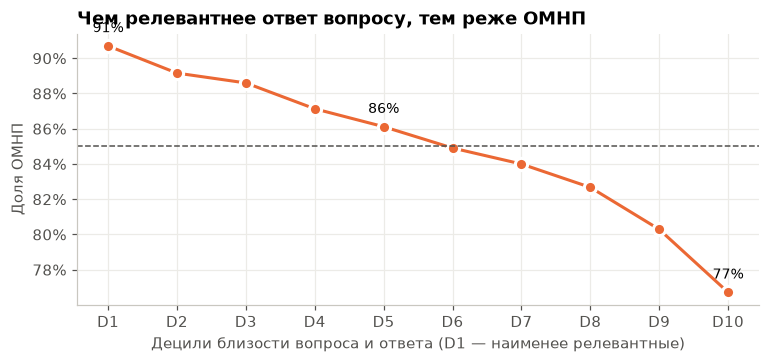

In [19]:
dec = df.groupby(pd.qcut(df.qa_sim, 10, labels=[f'D{i}' for i in range(1, 11)]), observed=True).omnp.mean()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(dec.index.astype(str), dec.values, color=C_OMNP, lw=2, marker='o', ms=8, markeredgecolor='white', markeredgewidth=2)
ax.axhline(BASE, color=C_INK2, ls='--', lw=1)
for i, v in enumerate(dec.values):
    if i in (0, 4, 9):
        ax.annotate(f'{v:.0%}', (i, v), xytext=(0, 9), textcoords='offset points', ha='center', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlabel('Децили близости вопроса и ответа (D1 — наименее релевантные)'); ax.set_ylabel('Доля ОМНП')
ax.set_title('Чем релевантнее ответ вопросу, тем реже ОМНП')
save(fig, '07_relevance_deciles')

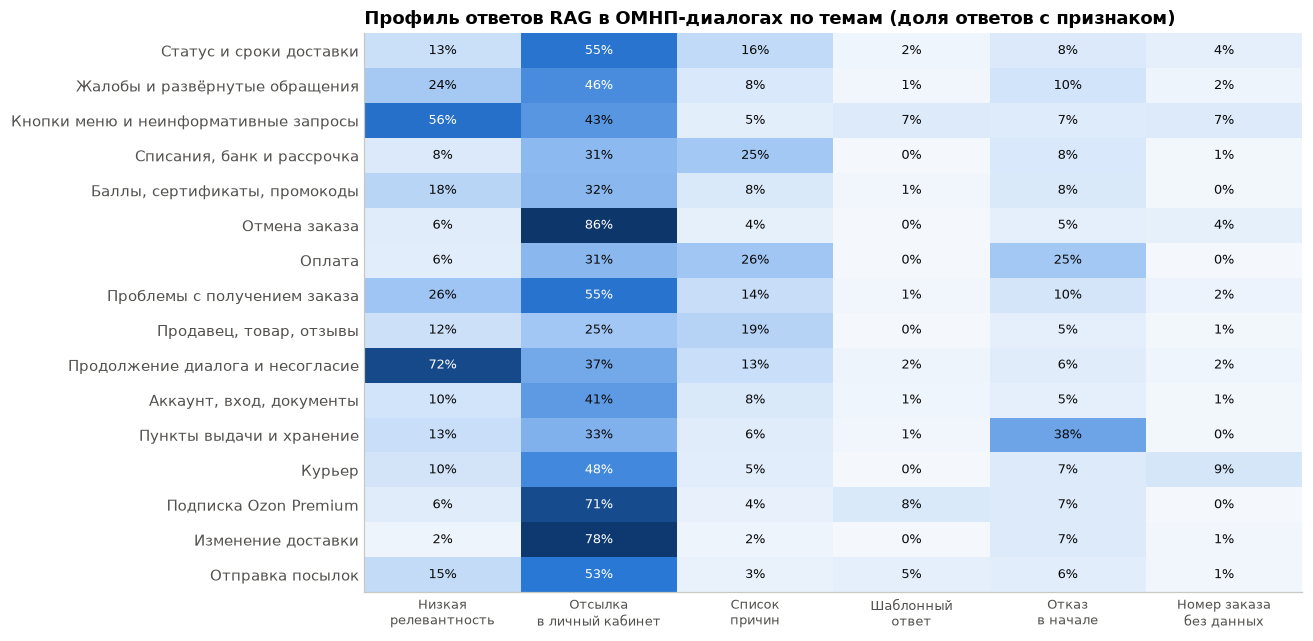

In [20]:
# Профиль проблем ответа по темам: доля ответов с признаком (только среди ОМНП)
prof_flags = ['a_low_rel', 'a_lk_redirect', 'a_reasons_list', 'a_template', 'a_refusal', 'a_order_echo']
prof = df[df.omnp == 1].groupby('theme')[prof_flags].mean()
prof = prof.loc[theme_t.index]                   # порядок: по объёму ОМНП
prof.columns = [FLAG_NAMES[c].split(' (')[0] for c in prof.columns]
prof.to_csv(TAB / '05_theme_answer_profile.csv')
fig, ax = plt.subplots(figsize=(11, 6.6))
blues = LinearSegmentedColormap.from_list('b', ['#f4f8fd', '#9ec5f4', '#2a78d6', '#0d366b'])
im = ax.imshow(prof.values, cmap=blues, vmin=0, vmax=0.8, aspect='auto')
for i in range(prof.shape[0]):
    for j in range(prof.shape[1]):
        v = prof.iat[i, j]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=8.5, color='white' if v > 0.45 else C_INK)
ax.set_xticks(range(prof.shape[1]), ['Низкая\nрелевантность', 'Отсылка\nв личный кабинет', 'Список\nпричин', 'Шаблонный\nответ', 'Отказ\nв начале', 'Номер заказа\nбез данных'], fontsize=8.5)
ax.set_yticks(range(len(prof)), prof.index); ax.grid(False); ax.tick_params(length=0)
ax.set_title('Профиль ответов RAG в ОМНП-диалогах по темам (доля ответов с признаком)')
save(fig, '08_theme_answer_profile')

In [21]:
# Примеры: наименее релевантные ответы в крупнейших ОМНП-кластерах
for c in clu_t.sort_values('excess_omnp', ascending=False).index.get_level_values(0)[:5]:
    sub = df[(df.q_cluster == c) & (df.omnp == 1)].nsmallest(2, 'qa_sim')
    print(f'\n=== {qnames.loc[c, "name"]}')
    for _, r in sub.iterrows():
        print(f'  Q: {norm_a(r.user_message)[:160]}\n  A: {norm_a(r.rag_answer)[:220]}  (sim={r.qa_sim:.3f})')


=== Развёрнутые претензии и жалобы (разные темы)
  Q: Да какие нафиг проблемы в пути , что снегопад чтоли , вы прикалываетесь что ли , вы лапшу то на уши мне не вешайте
  A: Если дата доставки не указана и заказ находится в статусе «Уточняем» или «Дата доставки скоро появится», информация о доставке обновляется. После обновления на странице заказа появится актуальная дата. Чтобы посмотреть д  (sim=0.744)
  Q: На фото не очень понятна платформа, когда дома померила, то поняла, что бабушке в 70лет не возможно ходить, ноги устанут. Это для молодых
  A: Согласно условиям продажи товаров для физических лиц, клиент может вернуть товар надлежащего качества после получения. Возврат проводится при условии, что товар не был в употреблении, сохранены его товарный вид, потребит  (sim=0.763)

=== «Не могу… / нет…»: короткие описания проблем
  Q: Я его ещё не заказывала
  A: Чтобы оформить заказ на Ozon, выполните следующие действия: 1. Выберите товары и добавьте их в корзину. 2. Перейдите в раздел

## 6. ОМНП и «Спасибо»: где реакция расходится с ожидаемой

### 6.1 Один и тот же ответ получает разные реакции в зависимости от потребности
Берём кластеры ответов (KMeans, k = 40, по сути это статьи базы знаний) и сравниваем долю ОМНП на **один и тот же
тип ответа** у тех, кто хотел «узнать», и у тех, кто хотел «решить по своему заказу».

answer_centroids.npy: назначение по сохранённым центроидам
Средний разрыв: 10.7 п.п.; положителен в 98% кластеров ответов


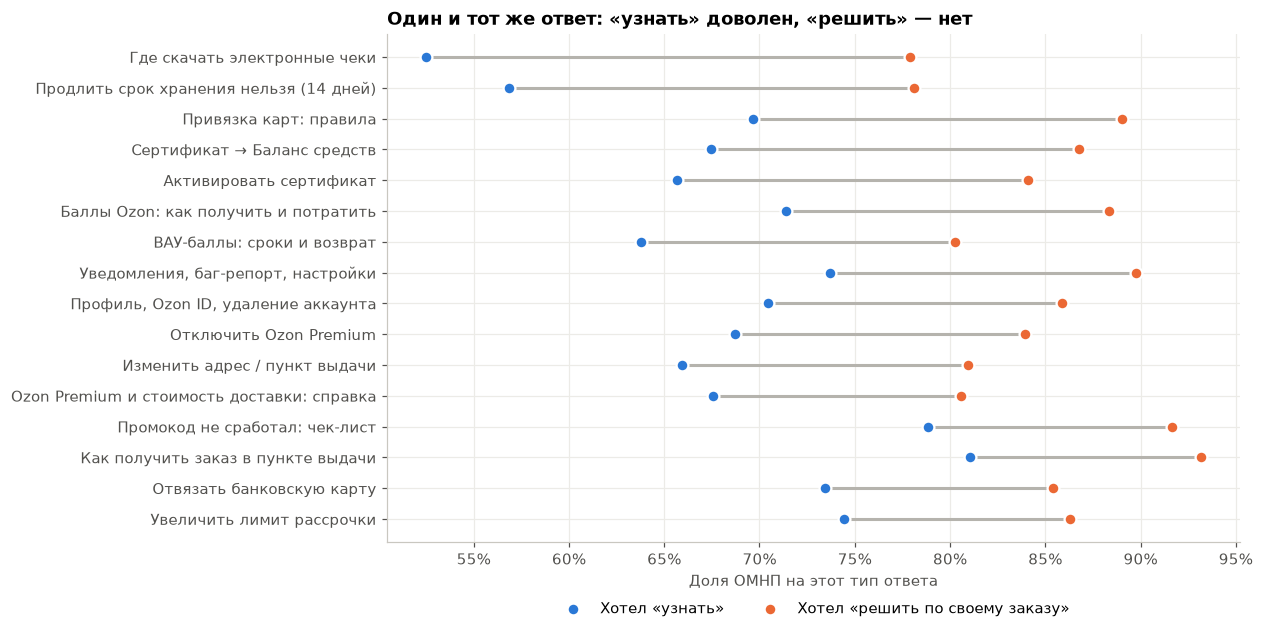

In [22]:
df['a_cluster'], anames = cluster(EA, N_A_CLUSTERS, DATA_DIR / 'answer_centroids.npy',
                                  DATA_DIR / 'answer_clusters.csv', a_text.str.lower())
df['a_name'] = df.a_cluster.map(anames['name'])
pv = df[df.need.isin(['Узнать', 'Решить по своему заказу'])].pivot_table(
    index='a_name', columns='need', values='omnp', aggfunc=['mean', 'size'])
pv = pv[(pv[('size', 'Узнать')] >= 80) & (pv[('size', 'Решить по своему заказу')] >= 80)]
gap = pd.DataFrame({'Узнать': pv[('mean', 'Узнать')], 'Решить': pv[('mean', 'Решить по своему заказу')],
                    'n_узнать': pv[('size', 'Узнать')], 'n_решить': pv[('size', 'Решить по своему заказу')]})
gap['Разрыв, п.п.'] = (gap['Решить'] - gap['Узнать']) * 100
gap = gap.sort_values('Разрыв, п.п.', ascending=False)
gap.to_csv(TAB / '06_same_answer_gap.csv')
print(f'Средний разрыв: {gap["Разрыв, п.п."].mean():.1f} п.п.; положителен в {(gap["Разрыв, п.п."] > 0).mean():.0%} кластеров ответов')

g = gap.head(16).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
yy = np.arange(len(g))
ax.hlines(yy, g['Узнать'], g['Решить'], color=C_GRAY, lw=2)
ax.scatter(g['Узнать'], yy, color=C_THX, s=60, zorder=3, edgecolor='white', linewidth=1.5, label='Хотел «узнать»')
ax.scatter(g['Решить'], yy, color=C_OMNP, s=60, zorder=3, edgecolor='white', linewidth=1.5, label='Хотел «решить по своему заказу»')
ax.set_yticks(yy, g.index); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=2, frameon=False); ax.set_xlabel('Доля ОМНП на этот тип ответа')
ax.set_title('Один и тот же ответ: «узнать» доволен, «решить» — нет')
save(fig, '09_same_answer_gap')

### 6.2 Модель «ожидаемой реакции» и неожиданные случаи
Градиентный бустинг по признакам вопроса и ответа (тип намерения, темы, стиль ответа, близость, PCA эмбеддингов).
Прогнозы out-of-fold, 5 фолдов. Затем ищем расхождения:
* **неожиданное «Спасибо»**: модель уверена в ОМНП (p ≥ 0.95), а человек поблагодарил;
* **неожиданный ОМНП**: модель скорее ждёт благодарности (p < 0.5), а человек нажал ОМНП.

In [23]:
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

pq = PCA(16, random_state=SEED).fit_transform(EQ)
pa = PCA(16, random_state=SEED).fit_transform(EA)
num_cols = ['q_words', 'q_short', 'q_long', 'q_order_ref', 'q_emotional', 'q_human', 'q_followup', 'q_status',
            'q_problem', 'q_action', 'q_info', 'qa_sim', 'a_chars', 'a_steps', 'a_yesno', 'a_refusal',
            'a_instruction', 'a_lk_redirect', 'a_reasons_list', 'a_no_info', 'a_order_echo', 'a_concrete', 'a_template']
X = np.hstack([df[num_cols].astype(float).values,
               df[['q_cluster', 'a_cluster']].values, pq, pa])
cat_mask = np.zeros(X.shape[1], bool); cat_mask[len(num_cols):len(num_cols) + 2] = True
yv = df.omnp.values
oof = np.zeros(len(df))
for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, yv):
    m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_leaf_nodes=31,
                                       categorical_features=cat_mask, random_state=SEED)
    oof[te] = m.fit(X[tr], yv[tr]).predict_proba(X[te])[:, 1]
df['p_omnp'] = oof
print(f'ROC-AUC out-of-fold: {roc_auc_score(yv, oof):.3f}')
cal = df.groupby(pd.qcut(df.p_omnp, 10), observed=True).agg(p=('p_omnp', 'mean'), fact=('omnp', 'mean'), n=('omnp', 'size'))
cal.round(3)

ROC-AUC out-of-fold: 0.726


,p,fact,n
p_omnp,,,
"(0.099, 0.694]",0.590,0.583,12000
"(0.694, 0.779]",0.740,0.738,11999
"(0.779, 0.833]",0.808,0.811,11999
"(0.833, 0.867]",0.851,0.849,11999
"(0.867, 0.889]",0.879,0.881,11999
"(0.889, 0.905]",0.897,0.898,11999
"(0.905, 0.919]",0.912,0.912,11999
"(0.919, 0.934]",0.927,0.922,11999
"(0.934, 0.95]",0.942,0.943,11999


In [24]:
hi_p, lo_p = 0.95, 0.5
df['surprise'] = np.select([(df.p_omnp >= hi_p) & (df.omnp == 0), (df.p_omnp < lo_p) & (df.omnp == 1)],
                           ['Неожиданное «Спасибо»', 'Неожиданный ОМНП'], default='')
print(df.surprise.value_counts())
sur = pd.crosstab(df.theme, df.surprise)
sur = sur.drop(columns='', errors='ignore')
sur['n'] = df.theme.value_counts()
for c in ['Неожиданное «Спасибо»', 'Неожиданный ОМНП']:
    sur[c + ', ‰'] = sur[c] / sur['n'] * 1000
sur = sur.sort_values('Неожиданный ОМНП, ‰', ascending=False)
sur.to_csv(TAB / '06_surprises_by_theme.csv')
display(sur.round(1))
print('Неожиданные ОМНП по типу намерения:')
display(df[df.surprise == 'Неожиданный ОМНП'].intent.value_counts(normalize=True).round(3).to_frame('доля'))
cmp = pd.DataFrame({'Неожиданный ОМНП': df[df.surprise == 'Неожиданный ОМНП'][list(FLAG_NAMES)].mean(),
                    'Все ОМНП': df[df.omnp == 1][list(FLAG_NAMES)].mean(),
                    'Все «Спасибо»': df[df.omnp == 0][list(FLAG_NAMES)].mean()})
cmp.index = [FLAG_NAMES[i] for i in cmp.index]
cmp.to_csv(TAB / '06_surprise_answer_flags.csv')
display(cmp.round(3))

surprise
                         118749
Неожиданный ОМНП            837
Неожиданное «Спасибо»       406
Name: count, dtype: int64


surprise,Неожиданное «Спасибо»,Неожиданный ОМНП,n,"Неожиданное «Спасибо», ‰","Неожиданный ОМНП, ‰"
theme,,,,,
Отправка посылок,1,91,1389,0.7,65.5
"Баллы, сертификаты, промокоды",3,248,9074,0.3,27.3
Пункты выдачи и хранение,24,165,6096,3.9,27.1
Кнопки меню и неинформативные запросы,29,131,12100,2.4,10.8
Подписка Ozon Premium,2,24,2611,0.8,9.2
"Продавец, товар, отзывы",26,24,6200,4.2,3.9
"Списания, банк и рассрочка",11,39,10224,1.1,3.8
"Аккаунт, вход, документы",11,20,6150,1.8,3.3
Оплата,0,23,7272,0.0,3.2


Неожиданные ОМНП по типу намерения:


,доля
intent,
Информационный вопрос,0.815
Кнопка / тема без вопроса,0.123
Просьба о действии,0.026
Прочее утверждение,0.016
Жалоба / эмоции,0.007
Продолжение диалога,0.005
Проблема,0.004
Статус заказа,0.004
Запрос оператора,0.001


,Неожиданный ОМНП,Все ОМНП,Все «Спасибо»
Низкая релевантность (нижние 20% по близости вопрос–ответ),0.115,0.212,0.135
Отсылка в личный кабинет в начале ответа,0.262,0.456,0.384
Пошаговая инструкция «сделайте сами»,0.399,0.542,0.506
Список возможных причин вместо ответа,0.008,0.119,0.073
Шаблонный ответ (тот же текст ≥ 20 раз),0.057,0.017,0.016
Отказ / ограничение в начале ответа,0.263,0.100,0.137
Номер заказа в ответе без данных по нему,0.000,0.027,0.016
«Нет информации в базе знаний»,0.011,0.020,0.018
Прямой ответ «Да» / «Нет» первым словом,0.296,0.016,0.070
Конкретные сроки / суммы / проценты,0.369,0.447,0.443


In [25]:
for kind in ['Неожиданный ОМНП', 'Неожиданное «Спасибо»']:
    print(f'\n##### {kind}: примеры')
    sub = df[df.surprise == kind].sample(6, random_state=SEED)
    for _, r in sub.iterrows():
        print(f'p={r.p_omnp:.2f} | {r.q_name}\n  Q: {norm_a(r.user_message)[:150]}\n  A: {norm_a(r.rag_answer)[:200]}')


##### Неожиданный ОМНП: примеры
p=0.38 | Пункт выдачи: работа и оценка
  Q: Сколько раз товар можно оставлять на хранении в пункте выдачи
  A: Срок хранения заказа в пункте выдачи Ozon составляет 14 дней. Продлить этот срок нельзя. После истечения указанного времени заказ будет возвращен продавцу или утилизирован. Если вы не успели забрать т
p=0.48 | Продлить срок хранения
  Q: Когда можно будет продлит товар хранения?
  A: Срок хранения заказа в пункте выдачи Ozon составляет 14 дней. Продлить срок хранения заказа нельзя. Если вы не успеете забрать заказ, он будет возвращен продавцу или утилизирован (в случае международн
p=0.49 | Названия сервисов («озон премиум», «озон банк»)
  Q: Хотела бы узнать, на Озоне есть рассрочка?
  A: Да, на Ozon есть рассрочка. Это сервис **Ozon Рассрочка**, который позволяет оплачивать покупки на Ozon и в других магазинах с лимитом до 500 000 рублей. Особенности сервиса: - нет первого взноса; - п
p=0.49 | Отправить посылку (Ozon Доставка)
  Q: Как оформит

### 6.3 Расхождения по ручной разметке
Сколько ОМНП поставлено на корректный ответ и сколько «Спасибо» — на ответ, который по сути не решает задачу.

In [26]:
if HAS_LABELS:
    om, th = ml[ml.reaction == 'ОМНП'], ml[ml.reaction == 'Спасибо']
    good_omnp = (om.label.isin(['G', 'P'])).mean()
    bad_thx = (th.label.isin(['A', 'I', 'E', 'O', 'V', 'C', 'K'])).mean()
    lo1, hi1 = wilson((om.label.isin(['G', 'P'])).sum(), len(om))
    lo2, hi2 = wilson((th.label.isin(['A', 'I', 'E', 'O', 'V', 'C', 'K'])).sum(), len(th))
    print(f'ОМНП на корректный ответ или корректный отказ: {good_omnp:.0%} (95% ДИ {lo1:.0%}–{hi1:.0%})')
    print(f'«Спасибо» на ответ, не решающий задачу: {bad_thx:.0%} (95% ДИ {lo2:.0%}–{hi2:.0%})')

ОМНП на корректный ответ или корректный отказ: 23% (95% ДИ 17%–31%)
«Спасибо» на ответ, не решающий задачу: 22% (95% ДИ 13%–34%)


### 6.4 Один и тот же вопрос, разные ответы
Для частых одинаковых вопросов сравниваем реакцию на разные типы ответа. Так видно, **какой ответ лучше**
на тот же самый запрос.

In [27]:
df['q_norm'] = q_text.str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip().astype(object)
freq = df.q_norm[df.q_norm.str.contains(r'[а-яё]') & (df.q_norm != 'пусто')].value_counts()
rows = []
for q in freq[freq >= 60].index:
    sub = df[df.q_norm == q]
    g = sub.groupby('a_name').omnp.agg(['size', 'mean'])
    g = g[g['size'] >= 12]
    if len(g) >= 2:
        best, worst = g['mean'].idxmin(), g['mean'].idxmax()
        rows.append({'Вопрос': q, 'n': len(sub), 'Лучший тип ответа': best, 'ОМНП лучшего': g.loc[best, 'mean'],
                     'Худший тип ответа': worst, 'ОМНП худшего': g.loc[worst, 'mean'],
                     'Разница, п.п.': (g.loc[worst, 'mean'] - g.loc[best, 'mean']) * 100})
same_q = pd.DataFrame(rows).sort_values('Разница, п.п.', ascending=False)
same_q.to_csv(TAB / '06_same_question_answers.csv', index=False)
same_q.head(12).style.format({'ОМНП лучшего': '{:.0%}', 'ОМНП худшего': '{:.0%}', 'Разница, п.п.': '{:.0f}'}).hide(axis='index')

Вопрос,n,Лучший тип ответа,ОМНП лучшего,Худший тип ответа,ОМНП худшего,"Разница, п.п."
ответ мне не помог,83,Вопросы о товаре продавцу (Q&A),83%,Общая инструкция по заказу (ответ не по запросу),100%,17
другой заказ,615,Отменить заказ: инструкция,80%,Заказ «уточняется» / где заказ по номеру,92%,12
назад,90,Отменить заказ: инструкция,31%,Отменить заказ и вернуть деньги,37%,6
заказ,741,Статус заказа в личном кабинете (шаблон),94%,Отменить заказ: инструкция,100%,6
человек,307,Способы оплаты и оформление заказа,95%,Изменить адрес / пункт выдачи,100%,5
вопрос по заказу,125,Сроки доставки «неизвестны заранее»,89%,Где заказ: инструкция по статусу,94%,5
отменить заказ,1603,Отменить заказ: инструкция,90%,Отменить заказ и вернуть деньги,94%,4
где заказ,272,Статус заказа в личном кабинете (шаблон),96%,Заказ «уточняется» / где заказ по номеру,100%,4
где мой заказ,476,Статус заказа в личном кабинете (шаблон),97%,Заказ «уточняется» / где заказ по номеру,100%,3
отправить посылку,64,Как получить заказ в пункте выдачи,73%,Ozon Premium и стоимость доставки: справка,76%,2


### 6.5 Кнопки реакции как навигация
Часть нажатий отражает не оценку ответа, а **желание куда-то перейти**. «Человек» почти всегда заканчивается ОМНП:
это путь к оператору. «Назад» и «Главное меню» получают «Спасибо» в разы чаще базы: кнопку жмут, чтобы выйти.

In [28]:
NAV = ['человек', 'оператор', 'назад', 'главное меню', 'другое', 'другой заказ', 'нет', 'ответ мне не помог']
nav = (df[df.q_norm.isin(NAV)].groupby('q_norm').omnp.agg(n='size', omnp_rate='mean')
       .reindex(NAV).dropna().sort_values('omnp_rate'))
nav['ci_low'], nav['ci_high'] = wilson(nav.omnp_rate * nav.n, nav.n)
nav.to_csv(TAB / '06_navigation_reactions.csv')
nav.style.format({'omnp_rate': '{:.1%}', 'ci_low': '{:.1%}', 'ci_high': '{:.1%}', 'n': '{:.0f}'})

,n,omnp_rate,ci_low,ci_high
q_norm,,,,
назад,90,41.1%,31.5%,51.4%
главное меню,289,48.1%,42.4%,53.8%
другой заказ,615,86.8%,83.9%,89.3%
другое,70,91.4%,82.5%,96.0%
нет,86,95.3%,88.6%,98.2%
ответ мне не помог,83,96.4%,89.9%,98.8%
человек,307,99.3%,97.7%,99.8%
оператор,42,100.0%,91.6%,100.0%


## 7. Хорошие кластеры ответов-эталоны

### 7.1 Кластеры ответов с наименьшей долей ОМНП

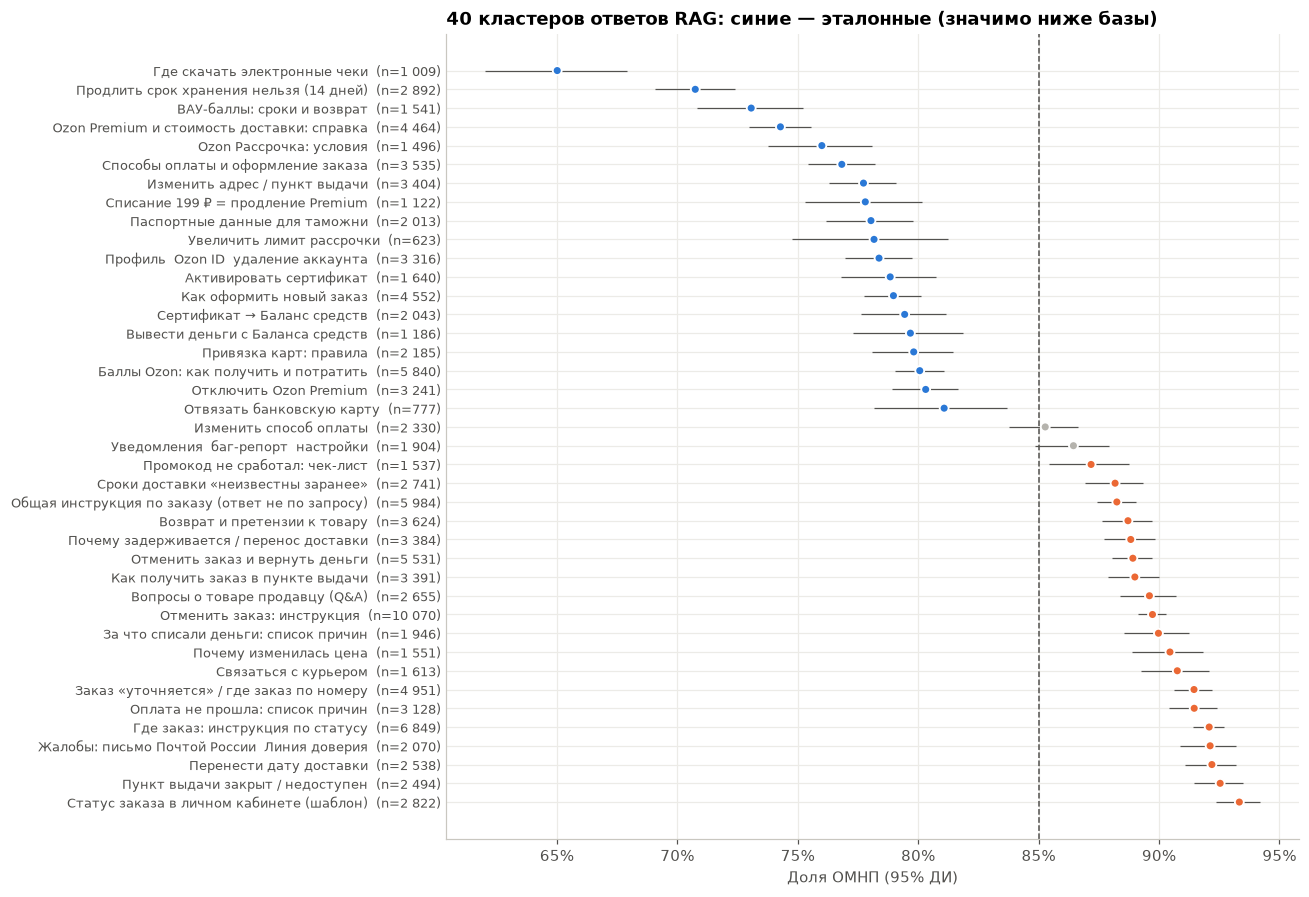

In [29]:
ans_t = rate_table(df, ['a_cluster', 'a_name'])
ans_t['main_question_theme'] = [df.loc[df.a_cluster == c, 'theme'].mode()[0] for c in ans_t.index.get_level_values(0)]
ans_t['need_info_share'] = [(df.loc[df.a_cluster == c, 'need'] == 'Узнать').mean() for c in ans_t.index.get_level_values(0)]
ans_t = ans_t.sort_values('omnp_rate')
ans_t.to_csv(TAB / '07_answer_clusters.csv')

t = ans_t.reset_index().iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 9.5))
yy = np.arange(len(t))
col = [C_THX if h < BASE else (C_OMNP if l > BASE else C_GRAY) for l, h in zip(t.ci_low, t.ci_high)]
ax.errorbar(t.omnp_rate, yy, xerr=[t.omnp_rate - t.ci_low, t.ci_high - t.omnp_rate], fmt='none', ecolor=C_INK2, lw=0.8)
ax.scatter(t.omnp_rate, yy, color=col, s=34, zorder=3, edgecolor='white', linewidth=1.2)
ax.axvline(BASE, color=C_INK2, ls='--', lw=1)
ax.set_yticks(yy, [f'{n}  (n={k:,})'.replace(',', ' ') for n, k in zip(t.a_name, t.n)], fontsize=8.5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.set_xlabel('Доля ОМНП (95% ДИ)')
ax.set_title('40 кластеров ответов RAG: синие — эталонные (значимо ниже базы)')
ax.tick_params(axis='y', length=0)
save(fig, '10_answer_clusters')

In [30]:
good = ans_t[ans_t.ci_high < BASE - 0.03]
print(f'Эталонных кластеров (верхняя граница ДИ ниже базы на 3+ п.п.): {len(good)}')
cols = ['n', 'omnp_rate', 'lift_pp', 'need_info_share', 'main_question_theme']
display(good[cols].style.format({'omnp_rate': '{:.1%}', 'lift_pp': '{:+.1f}', 'need_info_share': '{:.0%}'}))

# Эталонные формулировки: самые частые тексты с наименьшей долей ОМНП внутри хороших кластеров
etalons = (df[df.a_cluster.isin(good.index.get_level_values(0))]
           .groupby(['a_name', 'rag_answer']).omnp.agg(['size', 'mean']).reset_index())
etalons = (etalons[(etalons['size'] >= 6) & (etalons['mean'] <= 0.6)]
           .sort_values(['a_name', 'size'], ascending=[True, False]).groupby('a_name').head(1))
etalons.to_csv(TAB / '07_etalon_answers.csv', index=False)
for _, r in etalons.iterrows():
    print(f'\n[{r.a_name}] n={r["size"]}, ОМНП={r["mean"]:.0%}\n{norm_a(r.rag_answer)[:400]}')

Эталонных кластеров (верхняя граница ДИ ниже базы на 3+ п.п.): 18


,,n,omnp_rate,lift_pp,need_info_share,main_question_theme
a_cluster,a_name,,,,,
37,Где скачать электронные чеки,1009,65.0%,-20.0,44%,"Баллы, сертификаты, промокоды"
8,Продлить срок хранения нельзя (14 дней),2892,70.7%,-14.3,38%,Пункты выдачи и хранение
11,ВАУ-баллы: сроки и возврат,1541,73.1%,-12.0,42%,"Баллы, сертификаты, промокоды"
30,Ozon Premium и стоимость доставки: справка,4464,74.3%,-10.7,48%,Курьер
32,Ozon Рассрочка: условия,1496,76.0%,-9.0,40%,"Списания, банк и рассрочка"
5,Способы оплаты и оформление заказа,3535,76.8%,-8.2,44%,Оплата
2,Изменить адрес / пункт выдачи,3404,77.7%,-7.3,35%,Изменение доставки
27,Списание 199 ₽ = продление Premium,1122,77.8%,-7.2,23%,"Списания, банк и рассрочка"
21,Паспортные данные для таможни,2013,78.0%,-7.0,38%,"Аккаунт, вход, документы"



[Где скачать электронные чеки] n=35, ОМНП=46%
Электронные чеки можно скачать в личном кабинете в разделе [**Электронные чеки**](url Также все чеки приходят на электронную почту, указанную в профиле.

[Изменить адрес / пункт выдачи] n=6, ОМНП=50%
1. Перейдите в личный кабинет на странице заказа. 2. Нажмите **Адрес** или **Изменить адрес**. 3. Выберите адрес из списка или добавьте новый адрес доставки. 4. Нажмите **Подтвердить изменение**. Изменить адрес можно, если товары ещё не переданы в доставку. После смены адреса может измениться дата доставки. Изменить адрес и способ доставки не получится для: - заказов с Ozon Fresh; - товаров из-за 

[Отключить Ozon Premium] n=13, ОМНП=31%
Чтобы отключить подписку Ozon Premium, выполните следующие действия: 1. В личном кабинете перейдите в раздел [**Ozon Premium**](url 2. В блоке «Управлять» выберите **Отключить подписку → Продолжить**. 3. Укажите причину отмены и нажмите **Отменить подписку**. При отмене платной месячной подписки все преимущест

### 7.2 Какие свойства ответа связаны с меньшей долей ОМНП (с поправкой на тему и тип запроса)
Логистическая регрессия: `ОМНП ~ стиль ответа + релевантность + тема вопроса + тип намерения`.
Ниже — отношения шансов (OR) с 95% ДИ. OR < 1 означает, что свойство связано с меньшим числом ОМНП.
Это корреляция, не эффект: проверять надо A/B-тестом.

Pseudo R² = 0.066


,OR,lo,hi,p
Прямой «Да/Нет» первым словом,0.400,0.369,0.433,0.000
Релевантность (+1 σ близости),0.759,0.743,0.775,0.000
Отказ / ограничение в начале,0.847,0.803,0.894,0.000
Конкретные сроки / суммы,0.909,0.877,0.942,0.000
Шаблонный ответ,0.953,0.833,1.089,0.479
Длина ответа (+100 символов),1.040,1.032,1.048,0.000
Пошаговая инструкция,1.067,1.029,1.106,0.000
Номер заказа без данных,1.185,1.043,1.347,0.009
Отсылка в личный кабинет,1.235,1.189,1.284,0.000
«Нет информации»,1.400,1.239,1.583,0.000


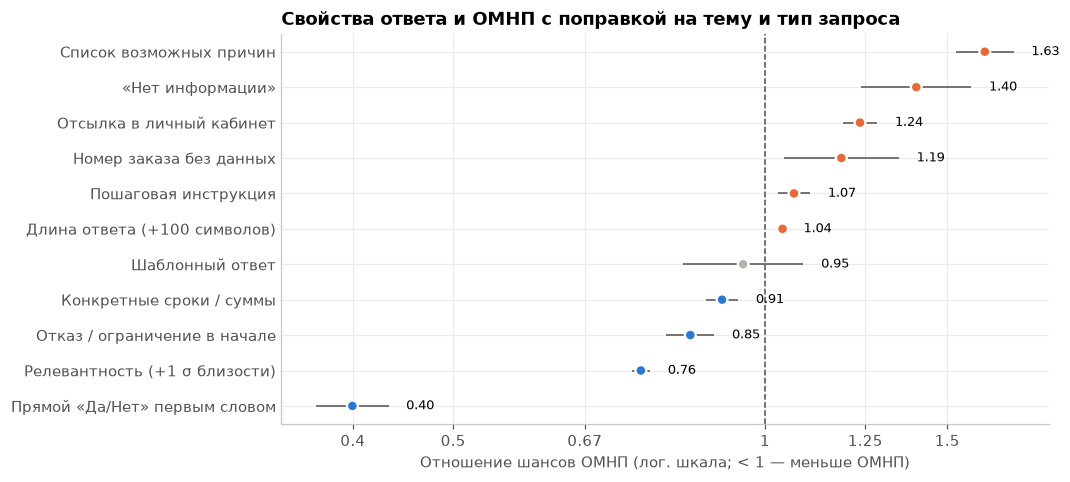

In [31]:
import statsmodels.formula.api as smf
m_df = df[['omnp', 'theme', 'intent', 'qa_sim', 'a_chars', 'a_yesno', 'a_refusal', 'a_instruction', 'a_lk_redirect',
           'a_reasons_list', 'a_no_info', 'a_order_echo', 'a_concrete', 'a_template']].copy()
m_df['qa_sim_z'] = (m_df.qa_sim - m_df.qa_sim.mean()) / m_df.qa_sim.std()
m_df['a_len_100'] = m_df.a_chars / 100
for c in m_df.columns:
    if m_df[c].dtype == bool:
        m_df[c] = m_df[c].astype(int)
formula = ('omnp ~ qa_sim_z + a_len_100 + a_yesno + a_refusal + a_instruction + a_lk_redirect + a_reasons_list'
           ' + a_no_info + a_order_echo + a_concrete + a_template + C(theme) + C(intent)')
logit = smf.logit(formula, data=m_df).fit(disp=0, maxiter=200)
STYLE = {'qa_sim_z': 'Релевантность (+1 σ близости)', 'a_len_100': 'Длина ответа (+100 символов)',
         'a_yesno': 'Прямой «Да/Нет» первым словом', 'a_refusal': 'Отказ / ограничение в начале',
         'a_instruction': 'Пошаговая инструкция', 'a_lk_redirect': 'Отсылка в личный кабинет',
         'a_reasons_list': 'Список возможных причин', 'a_no_info': '«Нет информации»',
         'a_order_echo': 'Номер заказа без данных', 'a_concrete': 'Конкретные сроки / суммы',
         'a_template': 'Шаблонный ответ'}
orr = pd.DataFrame({'OR': np.exp(logit.params), 'lo': np.exp(logit.conf_int()[0]), 'hi': np.exp(logit.conf_int()[1]),
                    'p': logit.pvalues}).loc[list(STYLE)]
orr.index = [STYLE[i] for i in orr.index]
orr = orr.sort_values('OR')
orr.to_csv(TAB / '07_style_odds_ratios.csv')
print(f'Pseudo R² = {logit.prsquared:.3f}')
display(orr.round(3))

fig, ax = plt.subplots(figsize=(9, 4.6))
yy = np.arange(len(orr))
col = [C_THX if h < 1 else (C_OMNP if l > 1 else C_GRAY) for l, h in zip(orr.lo, orr.hi)]
ax.errorbar(orr.OR, yy, xerr=[orr.OR - orr.lo, orr.hi - orr.OR], fmt='none', ecolor=C_INK2, lw=1)
ax.scatter(orr.OR, yy, color=col, s=50, zorder=3, edgecolor='white', linewidth=1.5)
ax.axvline(1, color=C_INK2, ls='--', lw=1); ax.set_xscale('log')
ax.xaxis.set_major_locator(mtick.FixedLocator([0.4, 0.5, 0.67, 1, 1.25, 1.5, 2]))
ax.xaxis.set_minor_locator(mtick.NullLocator())
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:g}'))
ax.set_yticks(yy, orr.index); ax.tick_params(axis='y', length=0)
for i, v in enumerate(orr.OR):
    ax.text(orr.hi.iloc[i] * 1.04, i, f'{v:.2f}', va='center', fontsize=8.5)
ax.set_xlabel('Отношение шансов ОМНП (лог. шкала; < 1 — меньше ОМНП)')
ax.set_title('Свойства ответа и ОМНП с поправкой на тему и тип запроса')
save(fig, '11_style_odds')

## 8. Масштаб проблем: откуда берутся ОМНП
Сводим всё в оценку: какая доля всех ОМНП приходится на каждый корень проблемы.
Сегменты по правилам взаимоисключающие (приоритет сверху вниз), поэтому доли складываются в 100%.

In [32]:
seg = np.select(
    [df.need == 'Эскалация',
     df.need == 'Решить по своему заказу',
     df.intent == 'Продолжение диалога',
     df.intent.isin(['Кнопка / тема без вопроса', 'Прочее утверждение']),
     df.a_low_rel,
    ],
    ['Жалоба / запрос оператора', 'Нужно действие или данные по своему заказу',
     'Продолжение диалога без контекста', 'Неясный запрос: бот угадывает тему',
     'Информационный вопрос: нерелевантный ответ'],
    default='Информационный вопрос: релевантный ответ')
df['root_cause'] = seg
rc = rate_table(df, 'root_cause')
rc = rc[['n', 'omnp_n', 'omnp_rate', 'omnp_share', 'traffic_share', 'lift_pp']]
rc.to_csv(TAB / '08_root_causes.csv')
rc.style.format({'omnp_rate': '{:.1%}', 'omnp_share': '{:.1%}', 'traffic_share': '{:.1%}', 'lift_pp': '{:+.1f}'})

,n,omnp_n,omnp_rate,omnp_share,traffic_share,lift_pp
root_cause,,,,,,
Нужно действие или данные по своему заказу,41225,36665,88.9%,35.9%,34.4%,+3.9
Неясный запрос: бот угадывает тему,30047,25752,85.7%,25.2%,25.0%,+0.7
Информационный вопрос: релевантный ответ,29074,21689,74.6%,21.3%,24.2%,-10.4
Жалоба / запрос оператора,12633,11734,92.9%,11.5%,10.5%,+7.9
Информационный вопрос: нерелевантный ответ,3842,3382,88.0%,3.3%,3.2%,+3.0
Продолжение диалога без контекста,3171,2806,88.5%,2.8%,2.6%,+3.5


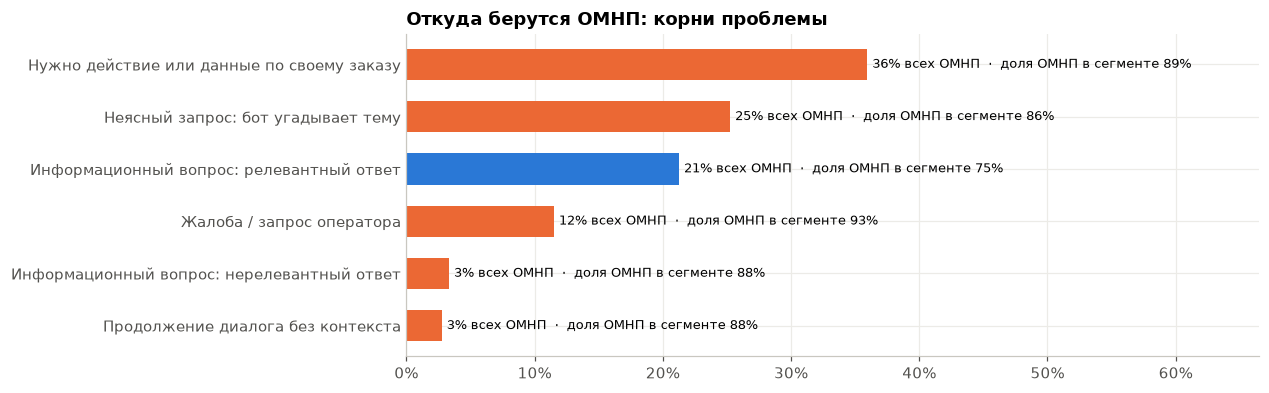

In [33]:
t = rc.sort_values('omnp_share')
fig, ax = plt.subplots(figsize=(10, 3.8))
yy = np.arange(len(t))
ax.barh(yy, t.omnp_share, color=[C_THX if 'релевантный ответ' in i and 'не' not in i else C_OMNP for i in t.index], height=0.6)
for i, (s, r) in enumerate(zip(t.omnp_share, t.omnp_rate)):
    ax.text(s + 0.004, i, f'{s:.0%} всех ОМНП  ·  доля ОМНП в сегменте {r:.0%}', va='center', fontsize=8.5)
ax.set_yticks(yy, t.index); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlim(0, t.omnp_share.max() * 1.85); ax.tick_params(axis='y', length=0)
ax.set_title('Откуда берутся ОМНП: корни проблемы')
save(fig, '12_root_causes')

## 9. Экспорт: дашборд и ключевые цифры
Дашборд — один HTML-файл (`dashboard/index.html`) с интерактивными графиками Plotly. Открывается в браузере без сервера.

In [34]:
import plotly.graph_objects as go

def fig_html(fig, h=420):
    fig.update_layout(height=h, margin=dict(l=10, r=10, t=40, b=10), font=dict(family='Inter, Arial', size=12),
                      plot_bgcolor='white', paper_bgcolor='white', hoverlabel=dict(bgcolor='white'))
    fig.update_xaxes(gridcolor='#ecebe7', zeroline=False); fig.update_yaxes(gridcolor='#ecebe7', zeroline=False)
    return fig.to_html(full_html=False, include_plotlyjs=False, config={'displayModeBar': False})

t = theme_t.sort_values('omnp_n')
f1 = go.Figure(go.Bar(x=t.omnp_n, y=t.index, orientation='h', marker_color=C_OMNP,
                      customdata=np.c_[t.omnp_rate * 100, t.n, t.lift_pp],
                      hovertemplate='<b>%{y}</b><br>ОМНП: %{x:,}<br>Доля ОМНП: %{customdata[0]:.1f}%<br>'
                                    'Обращений: %{customdata[1]:,}<br>К базе: %{customdata[2]:+.1f} п.п.<extra></extra>'))
f1.update_layout(title='Объём ОМНП по темам')

t = theme_t.sort_values('omnp_rate')
f2 = go.Figure(go.Scatter(x=t.omnp_rate * 100, y=t.index, mode='markers',
                          marker=dict(size=11, color=[C_OMNP if l > BASE else (C_THX if h < BASE else C_GRAY) for l, h in zip(t.ci_low, t.ci_high)],
                                      line=dict(color='white', width=2)),
                          error_x=dict(type='data', symmetric=False, array=(t.ci_high - t.omnp_rate) * 100,
                                       arrayminus=(t.omnp_rate - t.ci_low) * 100, color=C_INK2, thickness=1),
                          hovertemplate='<b>%{y}</b><br>Доля ОМНП: %{x:.1f}%<extra></extra>'))
f2.add_vline(x=BASE * 100, line_dash='dash', line_color=C_INK2)
f2.update_layout(title='Доля ОМНП по темам (95% ДИ), пунктир — база')

t = clu_t[clu_t.n >= 300].reset_index()
f3 = go.Figure(go.Scatter(x=t.n, y=t.omnp_rate * 100, mode='markers', text=t.q_name,
                          marker=dict(size=np.sqrt(t.omnp_n) / 2.2, color=C_OMNP, opacity=0.6, line=dict(color='white', width=1.5)),
                          customdata=np.c_[t.theme, t.keywords, t.omnp_n],
                          hovertemplate='<b>%{text}</b><br>%{customdata[0]}<br>Обращений: %{x:,}<br>Доля ОМНП: %{y:.1f}%<br>'
                                        'ОМНП: %{customdata[2]:,}<br>Ключевые слова: %{customdata[1]}<extra></extra>'))
f3.add_hline(y=BASE * 100, line_dash='dash', line_color=C_INK2)
f3.update_xaxes(type='log', title='Обращений в кластере'); f3.update_yaxes(title='Доля ОМНП, %')
f3.update_layout(title='50 кластеров вопросов')

f4 = go.Figure(go.Heatmap(z=hm.values * 100, x=hm.columns, y=hm.index, colorscale=[[0, '#fdf0ea'], [0.5, '#eb6834'], [1, '#a63f17']],
                          zmin=65, zmax=100, text=hn.values, hovertemplate='%{y} · %{x}<br>Доля ОМНП: %{z:.1f}%<br>n=%{text}<extra></extra>',
                          colorbar=dict(title='% ОМНП')))
f4.update_layout(title='Тема × тип потребности')

t = rc.sort_values('omnp_share')
f5 = go.Figure(go.Bar(x=t.omnp_share * 100, y=t.index, orientation='h', marker_color=C_OMNP,
                      customdata=np.c_[t.omnp_rate * 100, t.n],
                      hovertemplate='<b>%{y}</b><br>%{x:.1f}% всех ОМНП<br>Доля ОМНП в сегменте: %{customdata[0]:.1f}%<br>'
                                    'Обращений: %{customdata[1]:,}<extra></extra>'))
f5.update_layout(title='Корни проблемы: доля всех ОМНП')

t = ans_t.reset_index().sort_values('omnp_rate', ascending=False)
f6 = go.Figure(go.Scatter(x=t.omnp_rate * 100, y=t.a_name, mode='markers',
                          marker=dict(size=9, color=[C_THX if h < BASE else (C_OMNP if l > BASE else C_GRAY) for l, h in zip(t.ci_low, t.ci_high)],
                                      line=dict(color='white', width=1.5)),
                          customdata=np.c_[t.n, t.main_question_theme],
                          hovertemplate='<b>%{y}</b><br>Доля ОМНП: %{x:.1f}%<br>n=%{customdata[0]:,}<br>Чаще всего тема: %{customdata[1]}<extra></extra>'))
f6.add_vline(x=BASE * 100, line_dash='dash', line_color=C_INK2)
f6.update_layout(title='Кластеры ответов: синие — эталоны')

g2 = gap.head(16).iloc[::-1]
f7 = go.Figure()
for _, r in g2.iterrows():
    f7.add_trace(go.Scatter(x=[r['Узнать'] * 100, r['Решить'] * 100], y=[r.name, r.name], mode='lines',
                            line=dict(color=C_GRAY, width=2), showlegend=False, hoverinfo='skip'))
f7.add_trace(go.Scatter(x=g2['Узнать'] * 100, y=g2.index, mode='markers', name='Хотел «узнать»',
                        marker=dict(color=C_THX, size=10, line=dict(color='white', width=1.5)),
                        hovertemplate='%{y}<br>«Узнать»: %{x:.1f}% ОМНП<extra></extra>'))
f7.add_trace(go.Scatter(x=g2['Решить'] * 100, y=g2.index, mode='markers', name='Хотел «решить по заказу»',
                        marker=dict(color=C_OMNP, size=10, line=dict(color='white', width=1.5)),
                        hovertemplate='%{y}<br>«Решить»: %{x:.1f}% ОМНП<extra></extra>'))
f7.update_layout(title='Один и тот же ответ, разные ожидания', legend=dict(orientation='h', y=-0.12))

t = orr.iloc[::-1]
f8 = go.Figure(go.Scatter(x=t.OR, y=t.index, mode='markers',
                          marker=dict(size=10, color=[C_THX if h < 1 else (C_OMNP if l > 1 else C_GRAY) for l, h in zip(t.lo, t.hi)],
                                      line=dict(color='white', width=1.5)),
                          error_x=dict(type='data', symmetric=False, array=t.hi - t.OR, arrayminus=t.OR - t.lo, color=C_INK2, thickness=1),
                          hovertemplate='%{y}<br>OR = %{x:.2f}<extra></extra>'))
f8.add_vline(x=1, line_dash='dash', line_color=C_INK2); f8.update_xaxes(type='log')
f8.update_layout(title='Стиль ответа: отношение шансов ОМНП (< 1 — лучше)')

KPI = {
    'Диалогов': f'{len(df):,}'.replace(',', ' '),
    'Доля ОМНП': f'{BASE:.0%}',
    'ОМНП на запросы «решить по заказу»': f'{rc.loc["Нужно действие или данные по своему заказу", "omnp_share"]:.0%}',
    'ОМНП: «узнать» → «решить»': f'{df[df.need=="Узнать"].omnp.mean():.0%} → {df[df.need=="Решить по своему заказу"].omnp.mean():.0%}',
}
N_STR = f'{len(df):,}'.replace(',', ' ')
kpi_html = ''.join(f'<div class="kpi"><div class="v">{v}</div><div class="l">{k}</div></div>' for k, v in KPI.items())
charts = [(f1, 520), (f2, 520), (f5, 380), (f4, 520), (f3, 560), (f7, 560), (f6, 900), (f8, 440)]
blocks = ''.join(f'<section class="card">{fig_html(f, h)}</section>' for f, h in charts)
html = f'''<!doctype html><html lang="ru"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1">
<title>ОМНП: дашборд</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/plotly.js/2.35.2/plotly.min.js"></script>
<style>
:root{{--bg:#f6f5f2;--card:#fff;--ink:#0b0b0b;--ink2:#52514e;--line:#e4e2dc}}
body{{margin:0;background:var(--bg);color:var(--ink);font-family:Inter,Arial,sans-serif}}
main{{max-width:1180px;margin:0 auto;padding:24px 16px 48px}}
h1{{font-size:26px;margin:0 0 4px}} p.sub{{color:var(--ink2);margin:0 0 20px;max-width:880px;line-height:1.45}}
.kpis{{display:grid;grid-template-columns:repeat(auto-fit,minmax(200px,1fr));gap:12px;margin-bottom:16px}}
.kpi{{background:var(--card);border:1px solid var(--line);border-radius:10px;padding:14px 16px}}
.kpi .v{{font-size:28px;font-weight:700}} .kpi .l{{color:var(--ink2);font-size:13px;margin-top:2px}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(520px,1fr));gap:12px}}
.card{{background:var(--card);border:1px solid var(--line);border-radius:10px;padding:8px;min-width:0}}
@media (max-width:600px){{.grid{{grid-template-columns:1fr}}}}
</style></head><body><main>
<h1>Почему пользователи нажимают «Ответ мне не помог»</h1>
<p class="sub">RAG-чатбот поддержки Ozon, {N_STR} диалогов с нажатой кнопкой. Оранжевый — выше базовой доли ОМНП ({BASE:.0%}),
синий — значимо ниже, серый — не отличается. Наведите курсор на график, чтобы увидеть детали.</p>
<div class="kpis">{kpi_html}</div><div class="grid">{blocks}</div></main></body></html>'''
(DASH / 'index.html').write_text(html, encoding='utf-8')
print('Сохранено:', DASH / 'index.html')

Сохранено: /Users/kornilovartemiy/Desktop/Ozon_tech/dashboard/index.html


In [35]:
# Ключевые цифры для отчёта и презентации
facts = {
    'n': len(df), 'base_omnp': BASE,
    'need': rate_table(df, 'need')[['n', 'omnp_rate', 'traffic_share', 'omnp_share']].to_dict('index'),
    'intent': rate_table(df, 'intent')[['n', 'omnp_rate', 'traffic_share', 'omnp_share']].to_dict('index'),
    'root_causes': rc.to_dict('index'),
    'themes': theme_t[['n', 'omnp_n', 'omnp_rate', 'omnp_share', 'lift_pp']].to_dict('index'),
    'relevance_deciles': dec.to_dict(),
    'auc_oof': float(roc_auc_score(yv, oof)),
    'same_answer_gap_mean_pp': float(gap['Разрыв, п.п.'].mean()),
    'same_answer_gap_positive_share': float((gap['Разрыв, п.п.'] > 0).mean()),
    'n_good_answer_clusters': int(len(good)),
    'navigation': nav.to_dict('index'),
    'surprises': df.surprise.value_counts().to_dict(),
    'style_or': orr.to_dict('index'),
    'flags': flags_t.set_index('Признак ответа').to_dict('index'),
}
if HAS_LABELS:
    facts['manual'] = {'omnp_good_or_policy': float(good_omnp), 'thanks_not_solving': float(bad_thx),
                       'omnp_label_share': (om.label.value_counts(normalize=True)).to_dict(),
                       'thx_label_share': (th.label.value_counts(normalize=True)).to_dict()}
(TAB / 'key_facts.json').write_text(json.dumps(facts, ensure_ascii=False, indent=1, default=float), encoding='utf-8')
print(json.dumps({k: facts[k] for k in ['base_omnp', 'auc_oof', 'same_answer_gap_mean_pp', 'n_good_answer_clusters']}, indent=1))

{
 "base_omnp": 0.8502900193346223,
 "auc_oof": 0.7259408283183373,
 "same_answer_gap_mean_pp": 10.688641120883549,
 "n_good_answer_clusters": 18
}
